# Tracking AI Trends Through NLP-Powered Text Mining and Knowledge Extraction

## Stage 1: Data Cleaning, Preprocessing, and Exploratory Analysis

### AI Media Dataset

This notebook covers:
1. Data Collection & Cleaning
2. Text Preprocessing
3. Exploratory Data Analysis (EDA)
4. Entity & Relation Extraction
5. Knowledge Graph Construction
6. Topic Modeling
7. AI Disclaimer
8. Contributions

By: Samuel Amuzu, Nick Schaufelberger, Julian Purtschert

In [1]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.7 MB/s eta 0:00:00


## Libraries

In [2]:
# Load libraries
import pandas as pd
import os
import re
from bs4 import BeautifulSoup
import contractions
import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
import ast
from transformers import pipeline
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

## 1. Data Collection & Cleaning

### 1. 1 Data Exploration and Loading

We first loaded the AI media dataset into Python using pandas. The dataset contains 16,527 articles and 7 columns, including title, content, date, domain, URL, and tags. We explored the structure using .head(), .info(), and .shape() before performing cleaning steps such as removing unnecessary index columns and converting text fields into usable string format. We also checked what data type content is before text cleaning, it seemed like it was a list data type but each document of that column is a string.

In [3]:
# Mount Google Drive to access project files stored in the cloud
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load data and Explore the data
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ai_media_dataset_20250911.csv")
df.head()

,Unnamed: 0,title,date,content,domain,url,tags
0,88571,Ricoh to provide customer support for Agility ...,2024-09-11,['The Digit humanoid could work in distributio...,therobotreport,https://www.therobotreport.com/ricoh-provides-...,"['Robotics', 'Video', 'BostonDynamics']"
1,92022,MTV VMAs 2024: Live shopping is coming to the ...,2024-09-11,"['In this article', ""When viewers tune in to t...",cnbc,https://www.cnbc.com/2024/09/11/mtv-vmas-2024-...,['GenerativeAI']
2,81522,Open-source imagery is transforming investigat...,2024-09-11,['Open-source online imagery can play a vital ...,theconversation,https://www.theconversation.com/open-source-im...,"['Disinformation', 'Video', 'Deepfake', 'Infor..."
3,81521,"With China seeking AI dominance, Taiwan’ s eff...",2024-09-11,"['Tensions between China, Taiwan and the U.S. ...",theconversation,https://www.theconversation.com/with-china-see...,"['MilitaryAndDefense', 'Missiles', 'HighPerfor..."
4,63808,Study links EV charging stations to increased ...,2024-09-11,['Countries globally are rapidly transitioning...,phys,https://phys.org/news/2024-09-links-ev-station...,"['Causality', 'Planning']"


In [5]:
print(df.info())
print(df.shape)
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16527 entries, 0 to 16526
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  16527 non-null  int64 
 1   title       16527 non-null  object
 2   date        16527 non-null  object
 3   content     16527 non-null  object
 4   domain      16527 non-null  object
 5   url         16527 non-null  object
 6   tags        16527 non-null  object
dtypes: int64(1), object(6)
memory usage: 903.9+ KB
None
(16527, 7)
          Unnamed: 0
count   16527.000000
mean    81551.738731
std     27029.352525
min         6.000000
25%     75093.500000
50%     87261.000000
75%     99034.500000
max    109492.000000


In [6]:
# Checking what data type content is
df["content"].apply(type).value_counts()

,count
content,
<class 'str'>,16527


### 1. 2 Data and Text Cleaning

Before performing any analytical tasks, we conducted a systematic data cleaning process to ensure the dataset was consistent, reliable, and suitable for downstream NLP tasks such as sentiment analysis, entity recognition, and topic modeling. During initial exploration, we identified a column named Unnamed: 0 that was not of interest to us so it was removed to simplify the dataset structure. This reduced the dataset to its essential attributes: Title, Date, Content, Domain, URL and Tags.

We applied duplicate removal across the dataset. The check confirmed that no duplicate records were present.

Next, we inspected the data fot missing values but no missing values were detected in the fields ensuring completeness of our dataset.

Lastly, since the content column contains the primary textual material for analysis, we applied a structured normalization pipeline to prepare it for downstream tasks.

The following cleaning steps were performed:
1. HTML Removal - Using BeautifulSoup, we removed any embedded HTML tags that may have originated from web scraping processes
2. Contraction Expansion - We expanded contractions  to ensure consistent linguistic representation.
3. Lowercasing - All text was converted to lowercase to ensure uniform token representation and prevent duplicate token variations.
4. URL Removal - All hyperlinks were removed to prevent noise in textual analysis.
5. Removal of Special Characters - Non-alphanumeric characters were removed while preserving letters and numbers. This ensures cleaner input for: topic modeling, frequency analysis and vectorization
6. Whitespace Normalization - To remove extra spaces to maintain clean and consistent formatting.

This transformed, newly cleaned text was stored in a new column (content_clean), preserving the original content for reference.  

During the cleaning steps the following additional sources were conducted (both last accessed on March 5th, 2026):
- https://www.geeksforgeeks.org/nlp/text-preprocessing-for-nlp-tasks/
- https://medium.com/@devangchavan0204/complete-guide-to-text-preprocessing-in-nlp-b4092c104d3e

In [7]:
# Remove Unnamed Column
df = df.drop(columns=["Unnamed: 0"])

In [8]:
# Remove duplicates
df = df.drop_duplicates()
print("After removing duplicates, no duplicates found:", df.shape)

After removing duplicates, no duplicates found: (16527, 6)


In [9]:
# Checking for missing values
df.isnull().sum()

,0
title,0
date,0
content,0
domain,0
url,0
tags,0


In [10]:
import contractions

# Normalize content column
def clean_text(text):

    """
    Cleans a raw text string through a sequential normalization pipeline.

    Applies the following steps in order:
      1. HTML removal       – strips HTML tags and entities using BeautifulSoup
      2. Contraction fixing – expands contractions (e.g. "don't" → "do not")
      3. Lowercasing        – normalizes text to lowercase
      4. URL removal        – removes hyperlinks (http/https)
      5. Special characters – replaces non-alphanumeric characters with spaces
      6. Whitespace cleanup – collapses multiple spaces into one and strips edges

    Args:
        text (str): Raw input text to clean

    Returns:
        str: Cleaned and normalized text string,
             or an empty string if input is not a valid string
    """

    if not isinstance(text, str):
        return ""
    # Remove HTML
    text = BeautifulSoup(text, "html.parser").get_text()
     # Expand contractions (don't to do not)
    text = contractions.fix(text)
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    # Remove special characters (keep letters and numbers)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Apply function on the content column
df["content_clean"] = df["content"].apply(clean_text)

In [14]:
from google.colab import files
files.download("cleaned_ai_media_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2. Text Preprocessing

After completing the initial data cleaning part, we moved to text preprocessing in order to transform the article text into a consistent and analysis ready format. While the cleaned "content_clean" column already removed noise such as HTML, URLs, and unwanted symbols, it still contained many variations of the same words (e.g. “models” vs. “model”, “generated” vs. “generate”) as well as function words (e.g. “the”, “is”, “and”). Therefore, the goal of preprocessing was to normalize each document.

*Tokenization*

First, we applied tokenization using NLTK’s word_tokenize, which splits each document into individual word tokens. This step was necessary because most NLP algorithms such as TF-IDF and topic models operate on tokens rather than raw strings.

*Stopword Removal*

Next, we removed English stopwords using NLTK’s built-in stopword list. Stopwords are extremely common words that occur across almost all documents and typically add little topical value. Removing them helps us highlight more meaningful terms and reduce noise. However, after performing exploratory analysis, we realized there were still stop words in our word cloud so we came back to filter them properly in the preprocessing step and performing further exploratory analysis.

*Lemmatization*

Finally, we applied lemmatization using the WordNet lemmatizer. Lemmatization reduces words to their base form (lemma) (e.g. “systems” → “system”, “running” → “run”). This reduces redundancy in the vocabulary and improves the quality of downstream tasks.

The resulting processed text was stored in a new column "content_processed", ensuring the cleaned version remains available for comparison and for later tasks that may require more natural sentence structure.

Our initial plan for exploration was to use spaCy, however, although spaCy provides an integrated and linguistically rich preprocessing pipeline (tokenization, POS tagging, lemmatization, parsing, and NER), it was computationally expensive for this dataset. With 16'527 articles, applying spaCy across the full corpus required significantly more runtime, especially because the default model pipeline includes heavier components such as dependency parsing and named entity recognition.

Since the primary goal of this preprocessing step was to prepare text for statistical analyses (e.g. TF-IDF, word frequency analysis, and topic modeling), we prioritized efficiency and reproducibility. However this choice does not prevent us from using spaCy later. We can still apply spaCy’s full pipeline during the Entity & Relation Extraction step, where its NER capabilities are required. In other words, we used NLTK for scalable corpus preprocessing, and we reserve spaCy for tasks where its richer linguistic features add clear value.

In [ ]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

# English stop words
stop_words = set(stopwords.words("english"))

# Add custom stopwords relevant to news articles
custom_stopwords = {
      # original ones
    "say", "said", "use", "used", "using", "also", "would", "could", "make",
    "made", "making", "get", "got", "getting", "one", "two", "three", "new",
    "need", "like", "well", "even", "still", "many", "much", "way", "come",
    "go", "going", "take", "taking", "know", "look", "want", "give", "think",
    "year", "time", "day", "week", "month", "company", "people", "world",
    "first", "last", "next", "back", "part", "us", "will", "may", "now",
    "though", "however", "including", "according", "without", "within",
    # new ones from the word cloud
    "example", "see", "mean", "include", "case", "thing", "around",
    "another", "every", "whether", "something", "yet", "already", "rather",
    "often", "alway", "always", "really", "lot", "sure", "good", "right",
    "different", "kind", "early", "long", "large", "real", "given", "based",
    "found", "run", "set", "end", "add", "call", "show", "move", "put",
    "point", "number", "area", "term", "place", "course", "plan", "step",
    "today", "five", "stock", "fact", "level", "bring", "yous", "lead",
    "several", "method", "instance", "individual", "important", "working"
}

# Combine both sets the english stop words with the new custom ones
stop_words = stop_words.union(custom_stopwords)

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Keep important short tokens
keep_short = {"ai", "ml", "dl", "nlp", "vr", "ar", "us", "uk", "eu"}

def preprocess_nltk(text):

    """
    Full NLP preprocessing pipeline for a single text string.

    Applies the following steps in order:
      1. Lowercasing        – normalize text to avoid duplicate representations
      2. Tokenization       – split text into individual word tokens
      3. Length filtering   – remove tokens shorter than 3 characters (e.g. "ok", "hi")
                              unless they are in the keep_short whitelist
      4. Alpha filtering    – remove punctuation, numbers, and special characters
      5. Stopword removal   – remove common words with little semantic value (e.g. "the", "is")
      6. Lemmatization      – reduce words to their base form (e.g. "running" → "run")

    Args:
        text (str): Raw input text to preprocess

    Returns:
        str: A single cleaned string of space-joined tokens,
             or an empty string if input is not a valid string
    """

    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove short junk words
    tokens = [t for t in tokens if len(t) >= 3 or t in keep_short]

    # Remove punctuation and non-alphabetic tokens
    tokens = [t for t in tokens if t.isalpha()]

    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

# Apply function
df["content_processed"] = df["content_clean"].apply(preprocess_nltk)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
df.to_csv("preprocessed_ai_media_dataset.csv", index = False)

files.download("preprocessed_ai_media_dataset.csv")

In [ ]:
df.head(5)

,title,date,content,domain,url,tags,content_clean,content_processed
0,Ricoh to provide customer support for Agility ...,2024-09-11,['The Digit humanoid could work in distributio...,therobotreport,https://www.therobotreport.com/ricoh-provides-...,"['Robotics', 'Video', 'BostonDynamics']",the digit humanoid could work in distribution ...,digit humanoid work distribution retail commer...
1,MTV VMAs 2024: Live shopping is coming to the ...,2024-09-11,"['In this article', ""When viewers tune in to t...",cnbc,https://www.cnbc.com/2024/09/11/mtv-vmas-2024-...,['GenerativeAI'],in this article when viewers tune in to the 20...,article viewer tune mtv vmas wednesday night a...
2,Open-source imagery is transforming investigat...,2024-09-11,['Open-source online imagery can play a vital ...,theconversation,https://www.theconversation.com/open-source-im...,"['Disinformation', 'Video', 'Deepfake', 'Infor...",open source online imagery can play a vital ro...,open source online imagery play vital role inv...
3,"With China seeking AI dominance, Taiwan’ s eff...",2024-09-11,"['Tensions between China, Taiwan and the U.S. ...",theconversation,https://www.theconversation.com/with-china-see...,"['MilitaryAndDefense', 'Missiles', 'HighPerfor...",tensions between china taiwan and the you s ar...,tension china taiwan limited aerial military m...
4,Study links EV charging stations to increased ...,2024-09-11,['Countries globally are rapidly transitioning...,phys,https://phys.org/news/2024-09-links-ev-station...,"['Causality', 'Planning']",countries globally are rapidly transitioning t...,country globally rapidly transitioning cleaner...


To verify that our cleaning and preprocessing pipeline is functioning as intended, we display a random sample of three articles showing the original content, the cleaned content_clean, and the fully preprocessed content_processed side by side. This allows us to visually confirm that HTML tags, URLs, and special characters have been correctly removed in the cleaning step, and that tokenization, stopword removal, and lemmatization have been properly applied in the preprocessing step.

In [ ]:
df[["content", "content_clean", "content_processed"]].sample(3)

,content,content_clean,content_processed
1162,"['At KPMG, we adopt a three-staged approach to...",at kpmg we adopt a three staged approach to ac...,kpmg adopt staged approach achieve regtech ena...
11303,['Artificial intelligence ( AI) is revolutioni...,artificial intelligence ai is revolutionizing ...,artificial intelligence ai revolutionizing ind...
2979,['The agriculture sector is riding the waves o...,the agriculture sector is riding the waves of ...,agriculture sector riding wave technological r...


## 3. Exploratory Data Analysis (EDA)

After cleaning and preprocessing the dataset, we conducted exploratory data analysis to better understand patterns, trends, and thematic structures in AI media coverage between September 2024 and August 2025.

The goal of this phase was threefold:
- To analyze how AI-related media coverage evolved over time.
- To examine sentiment variation across AI topics.
- To visually explore dominant themes in article content and titles.

We begin by analyzing some basic information of the dataset:

In [ ]:
# Basic stats

# Number of total articles
print("Total articles:", len(df))

# Date range / Timeline
print("Date range:", df["date"].min(), "→", df["date"].max())

# Number of unique domains
print("Unique domains:", df["domain"].nunique())

# Number of articles per domain and show the top 10
print("Articles per domain:")
print(df["domain"].value_counts().head(10))

Total articles: 16527
Date range: 2024-09-11 → 2025-08-24
Unique domains: 187
Articles per domain:
domain
builtin               719
aijourn               637
venturebeat           608
marketbeat            567
thenewstack           496
towardsdatascience    493
zacks                 437
theconversation       431
salesforce            388
gizmodo               357
Name: count, dtype: int64


### 3. 1 Temporal Analysis

To understand how AI media evolved during the respective period (Sep 24 to Aug 25), we first converted the date column into a proper datetime format. From this, we extracted the month component to aggregate articles on a monthly basis. We then grouped the dataset by month and counted the number of articles published in each period. This allowed us to generate a time-series plot illustrating fluctuations in AI media coverage over time.

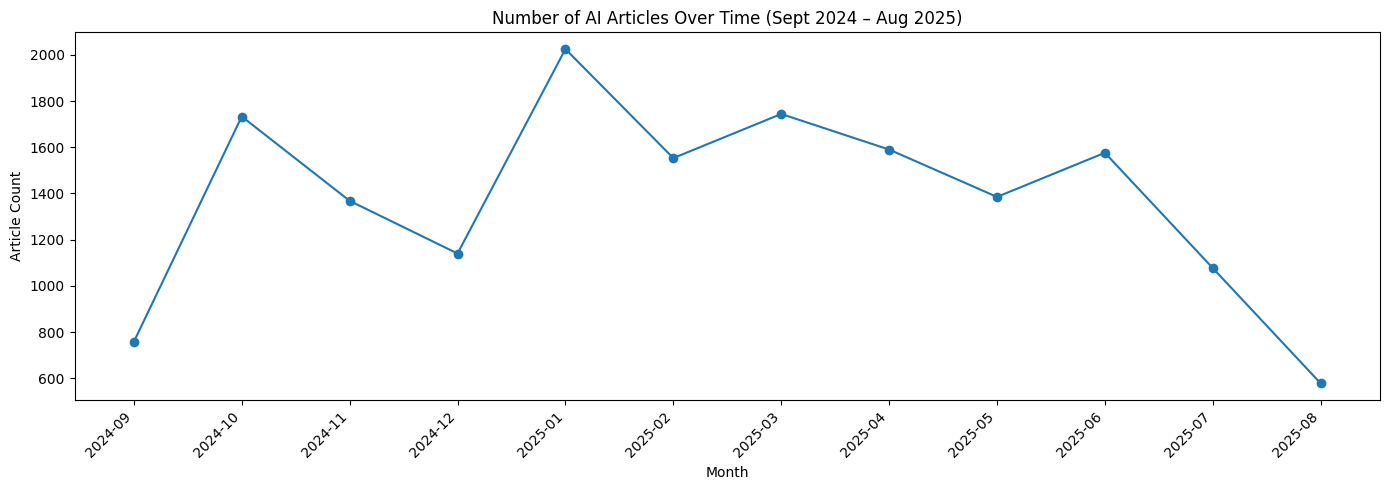

In [ ]:
# Convert to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Extract month
df["month"] = df["date"].dt.to_period("M")

# Count number of articles per month
monthly_counts = df.groupby("month").size().reset_index(name="count")

# Convert month to string for clean plotting
monthly_counts["month"] = monthly_counts["month"].astype(str)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(monthly_counts["month"], monthly_counts["count"], marker="o")

plt.xticks(rotation=45, ha="right")
plt.title("Number of AI Articles Over Time (Sept 2024 – Aug 2025)")
plt.xlabel("Month")
plt.ylabel("Article Count")

plt.tight_layout()
plt.show()

The overall number of AI articles ranges between 600 and 2'000 articles per month. The most notable periods in this visualization can be seen in the December 2024 and January 2025.
December 2024 shows a noticeable drop of around 1'150 articles. Driving factors could be attributed to reduced publishing activity over the holiday season at the end of the year.
January 2025 peaks at the highest point at around 2'000 articles, suggesting a surge of AI-related news at the start of the year. Likely tied to CES 2025 (one of the most powerful tech events in the world) and various new model releases in the beginning of the year.

Questionable is the steady decline from June 25 to August 25, which may relate to the dataset approaching its collection cutoff, rather than a genuine drop in AI coverage.

### 3. 2 Sentiment Analysis

To gain a comprehensive understanding of the emotional tone in AI media
coverage, we apply two complementary sentiment analysis approaches. First,
we use **TextBlob**, a lexicon-based method that provides a simple and
fast polarity score for each article. We then complement this with
**Cardiff NLP's RoBERTa-based model** (twitter-roberta-base-sentiment),
a transformer-based approach fine-tuned on real-world text data, which
provides more nuanced and accurate sentiment classifications of
**Negative**, **Neutral**, and **Positive**.


### 3. 2. 1 Textblob Sentiment Analysis

We begin with TextBlob, a simple lexicon-based approach that assigns
each article a polarity score between -1 (negative) and +1 (positive).

In [ ]:
from textblob import TextBlob
import ast

# Convert from strings into real lists
df["tags"] = df["tags"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Compute Sentiment scores per article from -1 (Negative) to 1 (Positive)
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment function to each document
df["sentiment"] = df["content_clean"].apply(get_sentiment)

# Explode tag column for each tag to have its own column
df_exploded = df.explode("tags")

# Compute average sentiment per Tag across all articles
sentiment_per_tag = (
    df_exploded
    .groupby("tags")["sentiment"]
    .mean()
    .sort_values(ascending=False)
)

sentiment_per_tag.head()

,sentiment
tags,
Protenus,0.425972
Helicone,0.295559
Photoroom,0.292202
Simplilearn,0.281539
MuseNet,0.262361


In [ ]:
# Classify into labels
df["sentiment_label"] = df["sentiment"].apply(
    lambda x: "positive" if x > 0.05 else ("negative" if x < -0.05 else "neutral")
)

print(df["sentiment_label"].value_counts())

sentiment_label
positive    15531
neutral       973
negative       23
Name: count, dtype: int64


### 3. 2. 2 Cardiff NLP sentiment analysis

We complement TextBlob with Cardiff NLP's RoBERTa-based transformer model,
which classifies each article as Negative, Neutral, or Positive with
greater contextual accuracy.

In [ ]:
from transformers import pipeline
import pandas as pd

# Load the Cardiff NLP Twitter-RoBERTa sentiment model
cardiff_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
# Run on content_clean
texts = df["content_clean"].fillna("").str[:512].tolist()

cardiff_results = []
batch_size = 32
for i in range(0, len(texts), batch_size):
    batch = texts[i : i + batch_size]
    cardiff_results.extend(cardiff_pipeline(batch))

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
# Extract label and score into new columns
df["cardiff_label"] = [r["label"].lower() for r in cardiff_results]
df["cardiff_score"] = [r["score"] for r in cardiff_results]

print(df["cardiff_label"].value_counts())

cardiff_label
neutral     8326
positive    7090
negative    1111
Name: count, dtype: int64


### 3. 2. 3 TextBlob vs. Cardiff NLP Comparison

To evaluate the consistency between both approaches, we directly compare
their sentiment classifications, highlighting where the two methods agree
and where they diverge.

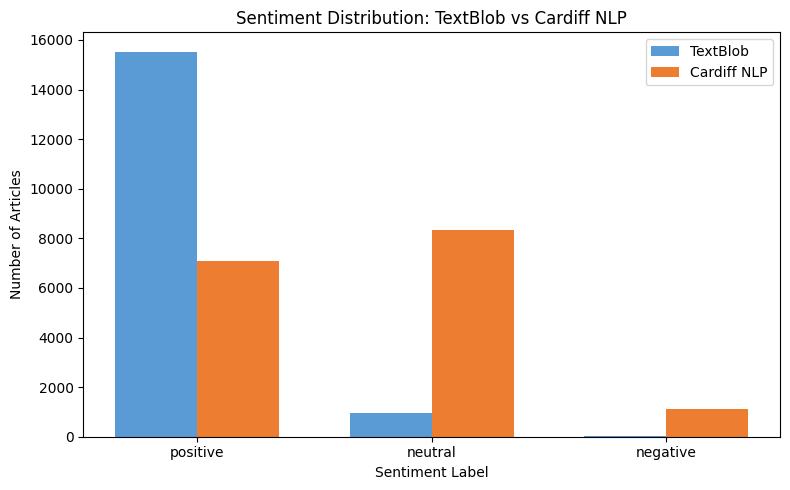

In [ ]:
import numpy as np
# Compare TextBlob vs Cardiff NLP label distributions
labels = ["positive", "neutral", "negative"]

textblob_counts = df["sentiment_label"].value_counts().reindex(labels, fill_value=0)
cardiff_counts  = df["cardiff_label"].value_counts().reindex(labels, fill_value=0)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, textblob_counts, width, label="TextBlob",       color="#5B9BD5")
ax.bar(x + width/2, cardiff_counts,  width, label="Cardiff NLP",    color="#ED7D31")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Sentiment Distribution: TextBlob vs Cardiff NLP")
ax.set_ylabel("Number of Articles")
ax.set_xlabel("Sentiment Label")
ax.legend()
plt.tight_layout()
plt.show()

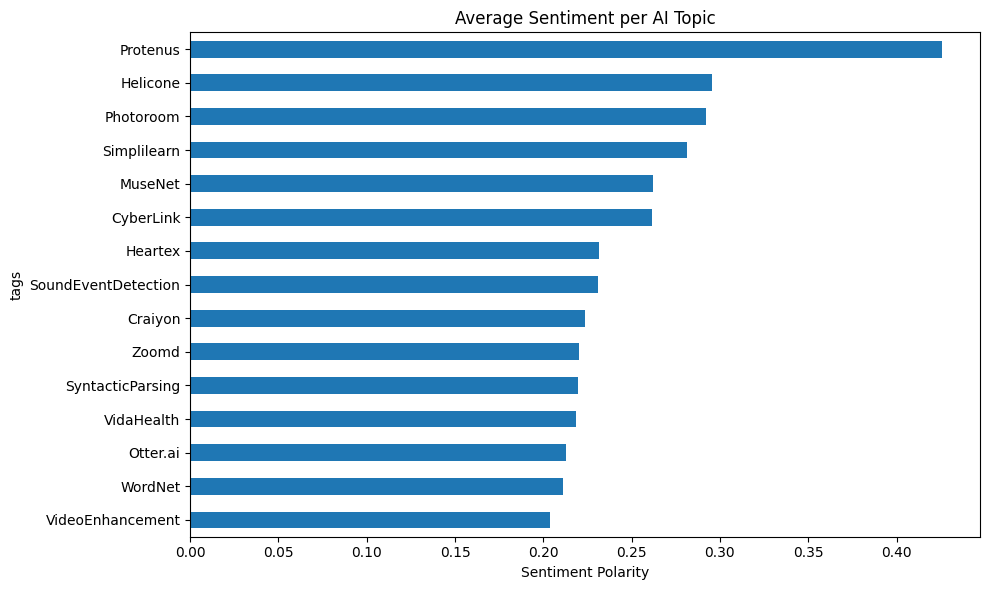

In [ ]:
# Select top 15 tags with the highest Sentiment Polarity
top_tags = sentiment_per_tag.head(15)

# Visualize them as horizontal bar plots
plt.figure(figsize=(10, 6))
top_tags.plot(kind="barh")
plt.title("Average Sentiment per AI Topic")
plt.xlabel("Sentiment Polarity")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

While TextBlob provides a fast and lightweight baseline for sentiment analysis, its lexicon-based approach was originally designed for general-purpose text and tends to over-predict positive sentiment, particularly on technical and news-style writing. This is clearly visible in our results: TextBlob classifies 15'531 articles as positive and only 23 as negative, which is an implausibly skewed distribution for a dataset covering topics such as AI regulation, job displacement, and ethical concerns. Cardiff NLP's RoBERTa-based model, by contrast, produces a far more balanced and credible distribution — 7'090 positive, 8'326 neutral, and 1'111 negative. For this reason, the Cardiff NLP labels are considered more reliable for downstream analysis such as topic-sentiment comparisons.  

The bar chart displays the average sentiment polarity scores with all scores falling in the range of 0.20 to 0.45, suggesting that AI media coverage was generally portrayed in a positive light. Protenus stands out as the most positively covered tag with a score of around 0.45., notably higher than the rest. Most cluster between the ranges of 0.20 and 0.30. The stable score range across various publishers shows, that there are no strongly negative narratives dominating AI media coverage in this time range and dataset.

### 3. 3 Word Cloud

### 3. 3. 1 Word Cloud on Content Tokens

To visually explore the dominant themes within the dataset, we performed a word cloud using the processed article content. Word clouds provide an intuitive way to highlight the most frequently occurring terms in a corpus, where larger words represent higher frequency.

First, we combined our processed documents (content_processed) into a single corpus string. This allows the WordCloud algorithm to compute the frequency of each token across all documents in the dataset.

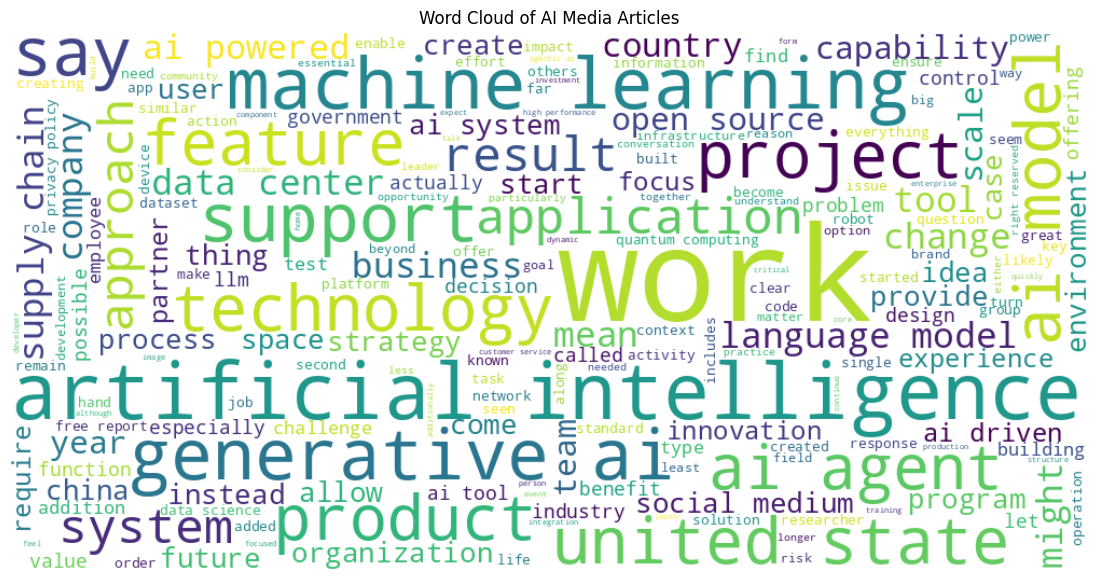

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combining all processed contents into one large string
text_corpus = " ".join(df["content_processed"])

# Generate Word Cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200
).generate(text_corpus)

# Visualize Word Cloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of AI Media Articles")
plt.show()

Words like "artifical intelligence", "machine learning", "generative ai" and "ai agent" are dominating the word cloud, as expected, given the dataset's focus. Notably, terms like "work", "application", "technology" and "support suggest that media coverage heavily emphasizes the practical and business applications of AI, rather than purely technical discussions.  
The presence of geopolitical terms such as "united states" and "china", also points to a discourse of global competition in AI.

### 3. 3. 2 Word Cloud on Title

In addition to full article content, a word cloud was also generated using the article titles. Titles often summarize the central idea of an article, making them useful for identifying headline-level trends and recurring topics in media coverage.

Compared to full article content, titles tend to be shorter and more focused, which can highlight more concise themes such as AI applications, technological developments, or major industry events. The title word cloud therefore provides a complementary perspective to the content-based analysis.

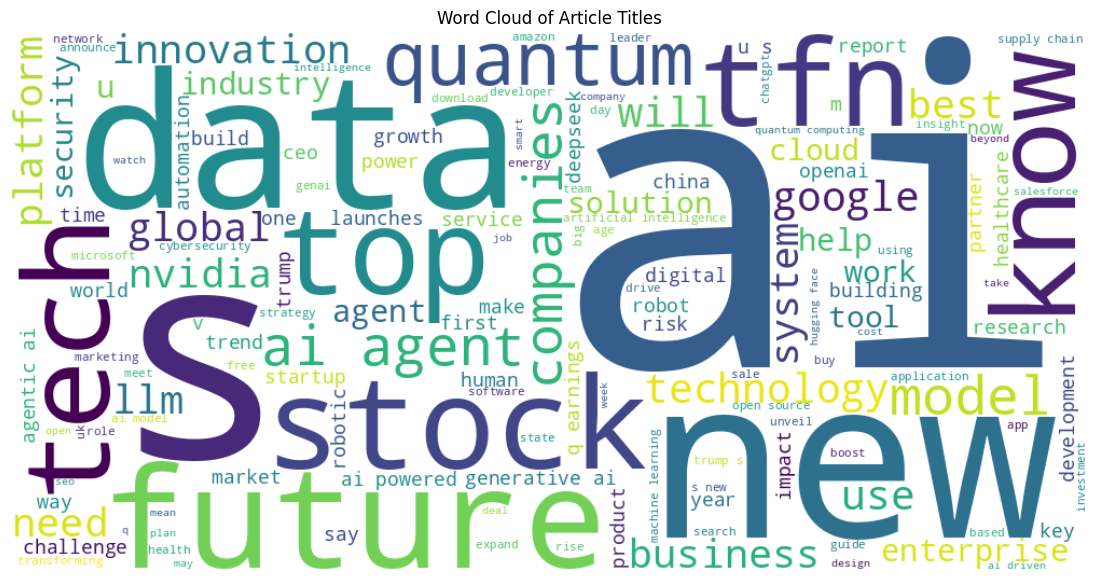

In [ ]:
import re

# Clean the titles column
def clean_title(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["title_clean"] = df["title"].apply(clean_title)

# Combine all titles together
title_corpus = " ".join(df["title_clean"])

# Generate Word Cloud
wordcloud_title = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=150
).generate(title_corpus)

# Plot
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_title, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Article Titles")
plt.show()

The word cloud of article titles reveals a strong focus on forward-lookgin and business-oriented language, with terms highlighted like "future", "new", "top" and "innovation" dominating. This suggests that AI media headlines tend to be aspirational and trend-driven.  
Specific technologies and companies such as "nvidia", "google", "open ai" and "deepseek" appear prominently, reflecting the media attention these key players received during the dataset period.  
Compared to the word cloud focusing on content, titles show a higher emphasis on financial and market themes such as "stock", "enterprise" and "quantum", indicating that headlines often frame AI through a business and investment perspective.

### 3. 3. 3 Word Cloud on Tags

Finally, a word cloud was created from the article tags provided in the dataset. Tags represent curated topic labels assigned to each article, such as specific technologies, companies, or AI subfields.

Unlike raw text, tags are already structured indicators of article topics, making them particularly useful for identifying the most prominent AI domains discussed in the media.

This tag-based visualization complements the content and title analyses by revealing which topics are explicitly emphasized by article categorization, helping to better understand the structure of AI-related discussions in the dataset.

In [ ]:
df["tags"].apply(type).value_counts()

,count
tags,
<class 'list'>,16527


In [ ]:
# All tags into one list
all_tags = [tag for tags in df["tags"] for tag in tags]

# Protect multi_word tags only if tags contain spaces
all_tags = [tag.replace(" ", "_") for tag in all_tags]

# Conver the list into a string
tags_corpus = " ".join(all_tags)

# Sanity check
print("Total tags used:", len(all_tags))

Total tags used: 85173


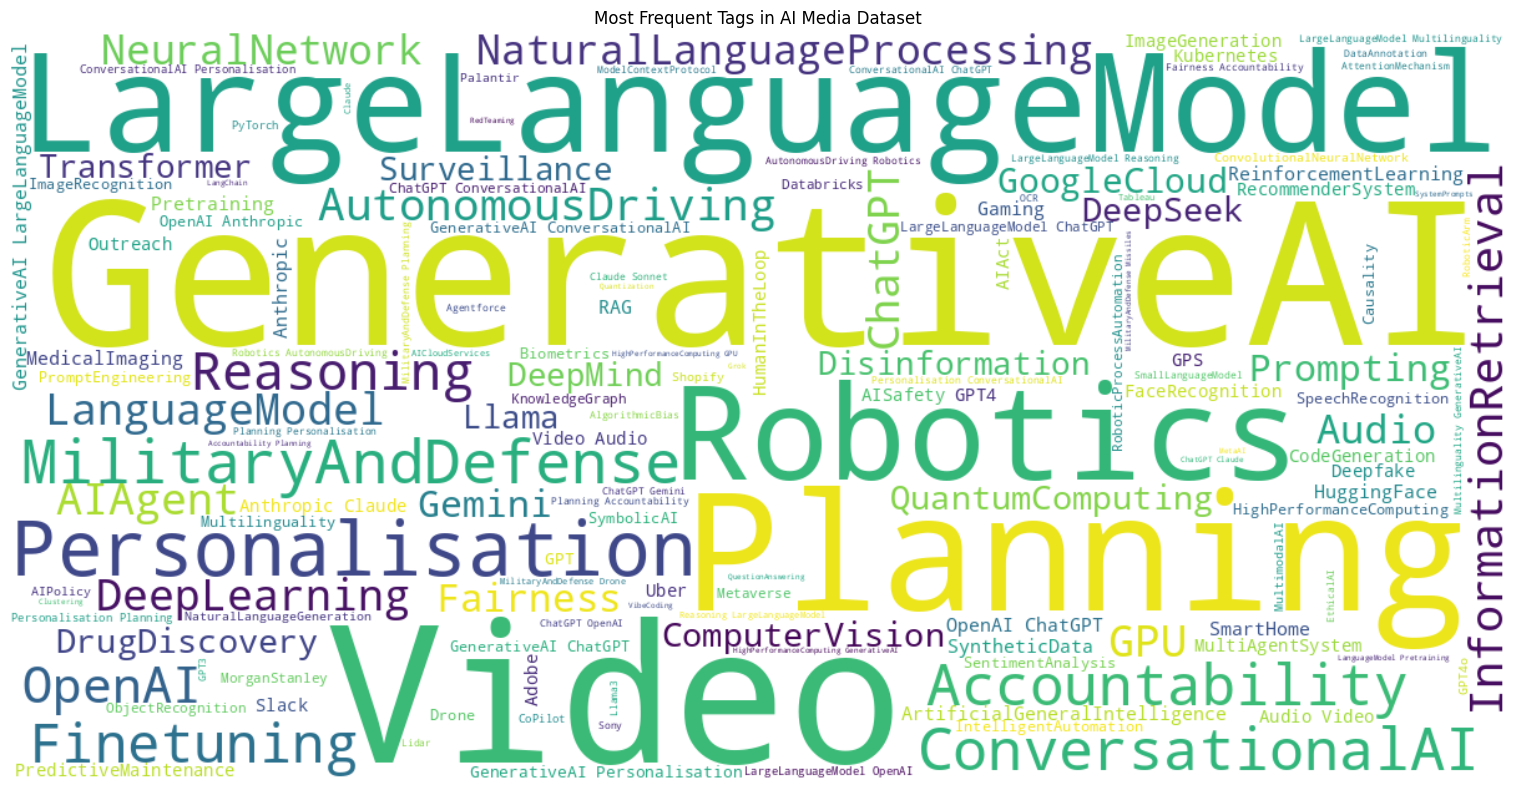

In [ ]:
# Generate word cloud
wordcloud_tags = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=150
).generate(tags_corpus)

# Plot
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud_tags, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Tags in AI Media Dataset")
plt.tight_layout()
plt.show()

The word cloud of the most frequent tags reveals that "Generative AI" and "Large Language Models" are one of the most tagged AI topics in the dataset, reflecting the dominance of LLM-related discourse in this timeframe between 2024 and 2025. Beyond those two topics, a diverse range of subfields appears. Prominently including "Robotics", "Video", "Planning" and "Personalisation". This suggests again that AI media coverage spans both technical and applied domains.  
Notably, ethics and governance-related tags such as "Fairness", "Accountability", "Disinformation" and "Military and Defense" are also visible, indicating that societal and regulatory concerns around AI received significant media attention.

### 3. 4 Top Tags Over Time

To understand how AI-related topics evolved over the studied period, the tags column was analyzed temporally. Each article in the dataset contains a list of tags representing the main topics discussed (e.g., GenerativeAI, ChatGPT, Robotics, AIpolicy). Since multiple tags can appear in a single article, the dataset was first expanded using the explode() function, allowing each tag to be represented as its own row. This transformation makes it possible to analyze the frequency of individual topics independently.

Next, we focused on the ten most frequently occurring tags across the entire dataset and visualized how interest in these topics changed over time, the data was grouped by month and tag, and the number of articles mentioning each tag was counted. This produces a time series of article counts for each topic, allowing us to observe patterns such as growth, decline, or sudden spikes in attention.

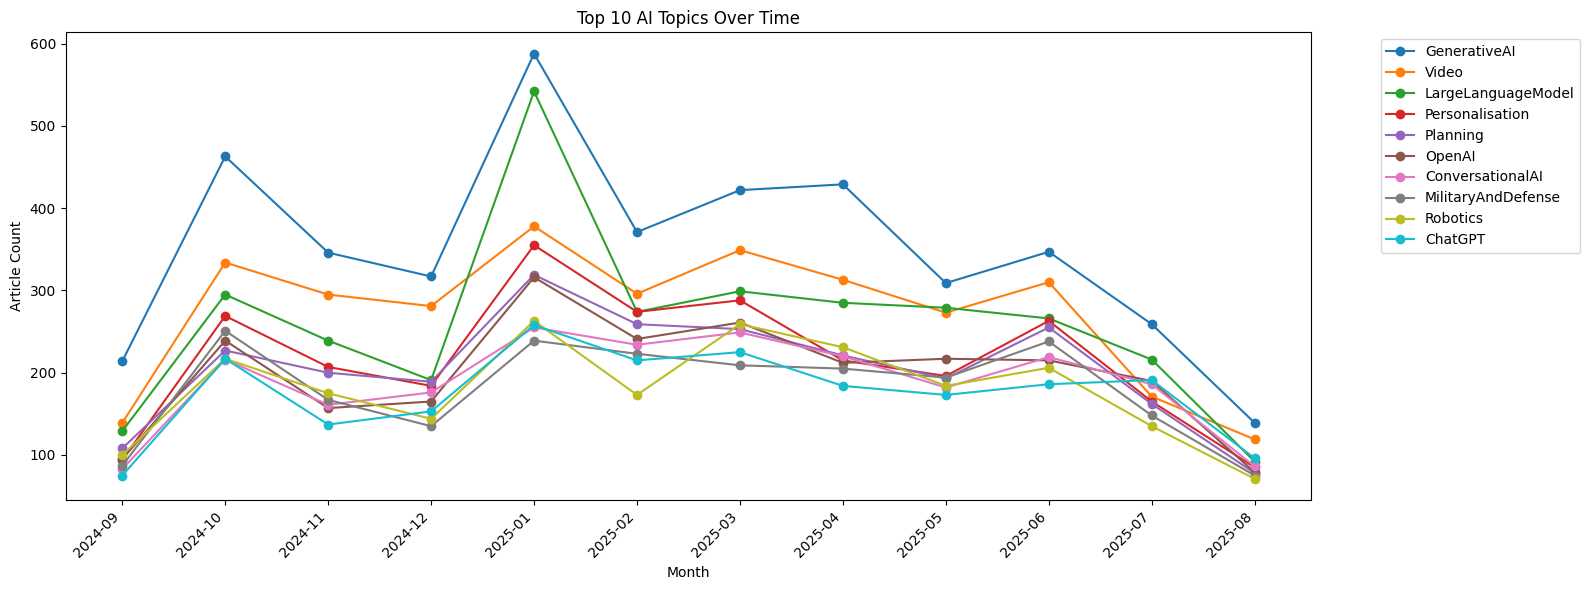

In [ ]:
# Explode tags so that each tag becomes its own row
df_tags = df.explode("tags").copy()

# Top 10 most frequent tags
top_tags = df_tags["tags"].value_counts().head(10).index.tolist()

# Group by the top 10 tags per Month
tag_time = (
    df_tags[df_tags["tags"].isin(top_tags)]
    .groupby(["month", "tags"])
    .size()
    .reset_index(name="count")
)

# Convert month to string for plotting
tag_time["month"] = tag_time["month"].astype(str)

# Plot topic trends over Time
plt.figure(figsize=(16, 6))

for tag in top_tags:
    subset = tag_time[tag_time["tags"] == tag]
    plt.plot(subset["month"], subset["count"], marker="o", label=tag)

plt.xticks(rotation=45, ha="right")
plt.title("Top 10 AI Topics Over Time")
plt.xlabel("Month")
plt.ylabel("Article Count")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The time-series plot shows that "Generative AI" consistently dominates media coverage across the entire period, peaking sharply in January 2025 at around 600 articles. A surge likely driven by major model releases and industry announcements at the start of the year.  
"Large Language Model" follows a very similar trajectory to "Generative AI", confirming that these two topics are closely intertwined. Most other topics remain relatively stable throughout the period, suggesting they represent consistent background themes rather than trend-driven spikes, with all topics showing a general decline toward August 2025 consistent with the dataset approaching its collection cutoff.

### 3. 5 TF-IDF Analysis

To further understand the importance of specific terms within the AI media dataset, we applied TF-IDF (Term Frequency–Inverse Document Frequency) which is a common technique in NLP used to identify words that are particularly informative within a collection of documents.

In this step, the preprocessed article content (content_processed) was transformed into a numerical representation using the TfidfVectorizer from Sklearn. Each document is converted into a vector where every column represents a term from the corpus, and the values correspond to the TF-IDF score of that term in the document. To improve the quality of the representation, we used two filtering parameters:

- max_df = 0.9 removes terms that appear in more than 90% of documents, as these words are usually too common to provide meaningful information.
- min_df = 5 ingores words appearing in fewer than 5 documents (too rare, likely noise)

After constructing the TF-IDF matrix, it was converted into a dataframe to allow further analysis. The average TF-IDF score for each term across all documents was then calculated to identify which words carry the most informational value in the corpus.  Finally, the top 20 terms with the highest average TF-IDF scores were visualized using a bar chart. This visualization highlights the most prominent keywords across the AI media articles and provides insight into the dominant themes discussed in the dataset.

In [ ]:
df["content_processed"].head(15)

,content_processed
0,digit humanoid work distribution retail commer...
1,article viewer tune mtv vmas wednesday night a...
2,open source online imagery play vital role inv...
3,tension china taiwan limited aerial military m...
4,country globally rapidly transitioning cleaner...
5,enterprise looking global capability center gc...
6,issue preventing website loading properly plea...
7,news news analysis commentary latest trend cyb...
8,problem climate change ongoing war covid pande...
9,field ai accelerating keeping track developmen...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Initialize vectorizer and remove words appearing in 90% of the documents and keep words only appearing in at least 5
vectorizer = TfidfVectorizer (max_df = 0.9, min_df = 5)
# Apply it to the content processed column
tfidf_matrix = vectorizer.fit_transform(df["content_processed"])

# To visualize it to an array of TF-IDF scores
print(tfidf_matrix.toarray())
print(vectorizer.get_feature_names_out())

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
['aaa' 'aaai' 'aachen' ... 'zyn' 'zync' 'zynga']


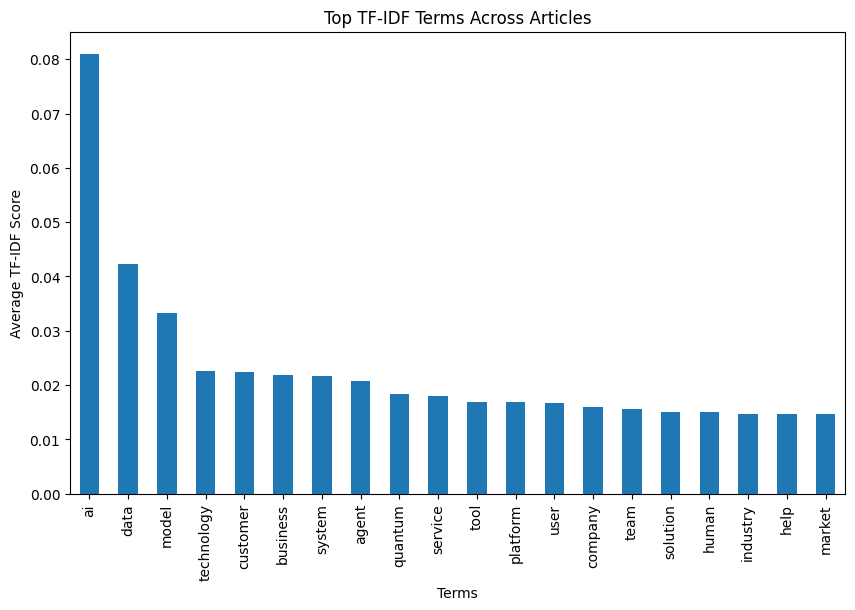

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert TF-IDF matrix to dataframe
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Average TF-IDF score for each term
mean_tfidf = df_tfidf.mean().sort_values(ascending=False)

# Top 20 terms
top_terms = mean_tfidf.head(20)

plt.figure(figsize=(10,6))
top_terms.plot(kind="bar")

plt.title("Top TF-IDF Terms Across Articles")
plt.xlabel("Terms")
plt.ylabel("Average TF-IDF Score")

plt.show()

The TF-IDF analysis confirms that "AI" is by far the most distinctive and frequently weighted term across all articles, followed by "data" and "model" at notably lower scores. It reflects that the dataset's core focus is on AI technology and data-driven systems.  
Terms like "agent", "quantum", "cloud" and "platform" appearing in the top 20 suggest that AI media coverage extends beyond research topics into infrastructure, business applications and emerging computing paradigms.  
The relatively flat distribution from "customer" onwwards indicates that most terms carry similarly moderate importance throughout the dataset, with no single term dominatinv as strongly as "AI" itself.

## 4. Entity & Relation Extraction

To extract named entities from the dataset, a pre-trained BERT-based NER model (dslim/bert-base-NER) was applied using the Hugging Face transformers pipeline. Since running the model on the full 16'000-article dataset would be computationally expensive and time-consuming, a representative sample of 2,000 rows was drawn in a first step (later the full dataset will be used) using a fixed random seed (random_state=42) to ensure reproducibility. The raw content field was used rather than the cleaned text, as named entities such as person names, locations, and organisations are better preserved in their original form.

In [ ]:
pip install torch transformers

In [ ]:
df["content_clean"].head()

,content_clean
0,the digit humanoid could work in distribution ...
1,in this article when viewers tune in to the 20...
2,open source online imagery can play a vital ro...
3,tensions between china taiwan and the you s ar...
4,countries globally are rapidly transitioning t...


In [ ]:
df["content_clean"].isna().sum()

np.int64(0)

In [ ]:
from transformers import pipeline
from collections import Counter, defaultdict

# NER model
ner_pipeline = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"
)

# Sample 2000 rows
df_sample = df.sample(n=2000, random_state=42).copy()

# Use raw uncleaned text instead of content_clean
texts = df_sample["content"].fillna("").str[:1000].tolist()

# Batch processing
results = ner_pipeline(texts, batch_size=16)

df_sample["content_entities"] = results

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
print(results)

[[{'entity_group': 'ORG', 'score': np.float32(0.9976306), 'word': 'B', 'start': 308, 'end': 309}, {'entity_group': 'MISC', 'score': np.float32(0.6014064), 'word': '##rail', 'start': 309, 'end': 313}, {'entity_group': 'ORG', 'score': np.float32(0.9969307), 'word': '##le Authority of North America', 'start': 313, 'end': 342}, {'entity_group': 'MISC', 'score': np.float32(0.9805778), 'word': 'Adobe Illustrator', 'start': 504, 'end': 521}, {'entity_group': 'MISC', 'score': np.float32(0.686177), 'word': 'Brail', 'start': 549, 'end': 554}, {'entity_group': 'ORG', 'score': np.float32(0.998722), 'word': 'MIT', 'start': 604, 'end': 607}, {'entity_group': 'ORG', 'score': np.float32(0.9989081), 'word': 'Computer Science and Artificial Intelligence Laboratory', 'start': 611, 'end': 666}, {'entity_group': 'ORG', 'score': np.float32(0.9880462), 'word': 'CSAIL', 'start': 669, 'end': 674}, {'entity_group': 'MISC', 'score': np.float32(0.93526596), 'word': 'Ta', 'start': 796, 'end': 798}, {'entity_group'

To explore the NER output, Claude was used to generate code that systematically unpacks and summarises the extracted entities. Counts entity types across the full sample using a Counter, and identifies the most frequently occurring words per entity group.

In [ ]:
# Explore results
all_entities = [ent for row in results for ent in row]

# raw output
print("=== Sample raw output (first 3 rows) ===")
for i, row in enumerate(results[:3]):
    print(f"\nRow {i}:", row)

# Summary stats
print("\n=== Entity type counts ===")
entity_types = Counter(ent["entity_group"] for ent in all_entities)
for etype, count in entity_types.most_common():
    print(f"  {etype}: {count}")

# Top words per entity type
print("\n=== Top words per entity type ===")
by_type = defaultdict(list)
for ent in all_entities:
    by_type[ent["entity_group"]].append(ent["word"].strip())

for etype, words in by_type.items():
    top = Counter(words).most_common(10)
    print(f"\n  {etype}: {top}")

# Add counts per row to df_sample
df_sample["entity_count"] = df_sample["content_entities"].apply(len)
df_sample["entity_types"] = df_sample["content_entities"].apply(
    lambda row: [e["entity_group"] for e in row]
)

print("\n=== Rows with most entities ===")
print(df_sample[["content", "entity_count"]].sort_values("entity_count", ascending=False).head(10))

=== Sample raw output (first 3 rows) ===

Row 0: [{'entity_group': 'ORG', 'score': np.float32(0.9976306), 'word': 'B', 'start': 308, 'end': 309}, {'entity_group': 'MISC', 'score': np.float32(0.6014064), 'word': '##rail', 'start': 309, 'end': 313}, {'entity_group': 'ORG', 'score': np.float32(0.9969307), 'word': '##le Authority of North America', 'start': 313, 'end': 342}, {'entity_group': 'MISC', 'score': np.float32(0.9805778), 'word': 'Adobe Illustrator', 'start': 504, 'end': 521}, {'entity_group': 'MISC', 'score': np.float32(0.686177), 'word': 'Brail', 'start': 549, 'end': 554}, {'entity_group': 'ORG', 'score': np.float32(0.998722), 'word': 'MIT', 'start': 604, 'end': 607}, {'entity_group': 'ORG', 'score': np.float32(0.9989081), 'word': 'Computer Science and Artificial Intelligence Laboratory', 'start': 611, 'end': 666}, {'entity_group': 'ORG', 'score': np.float32(0.9880462), 'word': 'CSAIL', 'start': 669, 'end': 674}, {'entity_group': 'MISC', 'score': np.float32(0.93526596), 'word': 

The NER model extracted a total of **21'014 entities** across the dataset, with **ORG** (9'250) being the most frequently detected entity type, followed by **MISC** (7'664), **LOC** (2'561), and **PER** (2'539), confirming that
AI media coverage is predominantly centered around organisations and technologies rather than individuals. The top entities per category align well with our earlier findings,  **Google, OpenAI, and Microsoft** dominate the ORG category, **U.S. and China** lead LOC, and **Trump** is the most
frequently mentioned person, reinforcing the dual technical and geopolitical framing of AI discourse. The articles with the highest entity counts (around 40-65 entities) tend to be press releases and news wires (PRNewswire, Associated Press), which naturally mention more named entities than opinion or analytical pieces.

Applying the previous steps to the full dataset.

In [ ]:
ner_pipeline = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="first"
)

# Full dataset
texts = df["content"].fillna("").str[:1000].tolist()

# Batch processing
results = ner_pipeline(texts, batch_size=16)

df["content_entities"] = results

# Attempt to clean up subword fragments
def merge_subwords(entities):
    merged = []
    for ent in entities:
        word = ent["word"]
        # If starts with ## or is a single char, merge with previous
        if merged and (word.startswith("##") or (len(word) <= 2 and word.isalpha())):
            prev = merged[-1]
            # Only merge if same entity group and adjacent
            if prev["entity_group"] == ent["entity_group"]:
                prev["word"] = prev["word"] + word.replace("##", "")
                prev["score"] = (prev["score"] + ent["score"]) / 2
                prev["end"] = ent["end"]
                continue
        merged.append(dict(ent))
    return merged

df["content_entities"] = df["content_entities"].apply(merge_subwords)
results_clean = df["content_entities"].tolist()

# Explore results
all_entities = [ent for row in results_clean for ent in row]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Explore results
all_entities = [ent for row in results_clean for ent in row]

# Raw output
print("=== Sample raw output (first 3 rows) ===")
for i, row in enumerate(results_clean[:3]):
    print(f"\nRow {i}:", row)

# Summary stats
print("\n=== Entity type counts ===")
entity_types = Counter(ent["entity_group"] for ent in all_entities)
for etype, count in entity_types.most_common():
    print(f"  {etype}: {count}")

# Top words per entity type
print("\n=== Top words per entity type ===")
by_type = defaultdict(list)
for ent in all_entities:
    by_type[ent["entity_group"]].append(ent["word"].strip())

for etype, words in by_type.items():
    top = Counter(words).most_common(10)
    print(f"\n  {etype}: {top}")

# Add counts per row
df["entity_count"] = df["content_entities"].apply(len)
df["entity_types"] = df["content_entities"].apply(
    lambda row: [e["entity_group"] for e in row]
)

print("\n=== Rows with most entities ===")
print(df[["content", "entity_count"]].sort_values("entity_count", ascending=False).head(10))

=== Sample raw output (first 3 rows) ===

Row 0: [{'entity_group': 'ORG', 'score': np.float32(0.6796642), 'word': 'Digit', 'start': 6, 'end': 11}, {'entity_group': 'ORG', 'score': np.float32(0.9964927), 'word': 'Agility Robotics', 'start': 124, 'end': 140}, {'entity_group': 'ORG', 'score': np.float32(0.99898857), 'word': 'Agility Robotics Inc', 'start': 144, 'end': 164}, {'entity_group': 'ORG', 'score': np.float32(0.99927425), 'word': 'Ricoh USA Inc', 'start': 205, 'end': 218}, {'entity_group': 'ORG', 'score': np.float32(0.997203), 'word': 'Ricoh', 'start': 278, 'end': 283}, {'entity_group': 'LOC', 'score': np.float32(0.99897766), 'word': 'North America', 'start': 349, 'end': 362}, {'entity_group': 'ORG', 'score': np.float32(0.702261), 'word': 'Digit', 'start': 449, 'end': 454}, {'entity_group': 'ORG', 'score': np.float32(0.98398256), 'word': 'Agility', 'start': 481, 'end': 488}, {'entity_group': 'ORG', 'score': np.float32(0.994463), 'word': 'Ricoh', 'start': 515, 'end': 520}, {'entity

Overall, the distributions look consistent, which suggests the model output is fairly stable.

Compared to the sample dataset and earlier output, the results are noticeably cleaner. In rows 0 and 1 especially, there is much less fragmentation. Multi-word entities such as Agility Robotics Inc, Ricoh USA Inc, and Paramount Global are correctly captured as single entities and with very high confidence (above 0.99).

The entity "Digit" being labeled as an ORG with lower confidence is understandable. Since it refers to a robot product name, it sits on the boundary between a product and an organization, so the lower confidence score is reasonable.

One clear issue appears in the MISC category. The repeated strings "AIAI", "AIAIAI", and "AIAIAIAI" point to a tokenization or aggregation bug. Most likely the token "AI" is being duplicated during entity grouping. This artificially inflates the MISC counts.

The LOC category looks much cleaner overall. Entries such as U.S., China, Europe, and India all make sense. However, items like "WashingtonDC" and "15th St NW" appearing in the top ten suggest that some articles contain unformatted address strings that are being interpreted as locations.

Finally, the PER entities provide a good indication of the editorial focus of the corpus. Frequent mentions of Trump (812), Musk (272), Sam Altman (126), and Jensen Huang (84) suggest the dataset centers on AI, technology, and politics people in the 2024–2025 period. The appearance of "Claude" (75) likely refers to Anthropic’s AI model rather than a person.

## 5. Lang Extract

LangExtract is a Python library that leverages LLMs to extract structured information from unstructured text based on user-defined prompts and examples. Due to API key limitations, we apply it to a sample of 10 article texts. It processes each article by identifying and organizing key entities and attributes, while grounding all extractions in the source text. https://github.com/google/langextract

In [ ]:
pip install langextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.6/124.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 10.0 MB/s eta 0:00:00


In [ ]:
import langextract as lx
import textwrap
import time

First, we create a prompt that clearly explains what information the model should extract. We are specific about the fields, format, and level of detail we would expect in the output.

In [ ]:
# Define prompt for entity + relation extraction
prompt = textwrap.dedent("""\
    Extract named entities (persons, organizations, locations) and relationships
    between them in order of appearance.
    Use exact text from the source for all extractions. Do not paraphrase.
    Add meaningful attributes to provide context for each entity or relation.""")

Next, we include a high-quality example that demonstrates the correct input and the desired output. This example acts as guidance for the model and helps it understand how to structure its response. The example was provided by an AI (Claude) for our explicit case.

In [ ]:
# Few-shot example to guide the model
examples = [
    lx.data.ExampleData(
        text="Apple CEO Tim Cook announced a new partnership with Google in San Francisco.",
        extractions=[
            lx.data.Extraction(
                extraction_class="entity",
                extraction_text="Apple",
                attributes={"type": "organization"}
            ),
            lx.data.Extraction(
                extraction_class="entity",
                extraction_text="Tim Cook",
                attributes={"type": "person", "role": "CEO"}
            ),
            lx.data.Extraction(
                extraction_class="relationship",
                extraction_text="Tim Cook announced a new partnership with Google",
                attributes={"type": "business_relation", "subject": "Tim Cook", "object": "Google"}
            ),
            lx.data.Extraction(
                extraction_class="entity",
                extraction_text="Google",
                attributes={"type": "organization"}
            ),
            lx.data.Extraction(
                extraction_class="entity",
                extraction_text="San Francisco",
                attributes={"type": "location"}
            ),
        ]
    )
]

This code randomly selects 10 rows from the dataset to create a small test sample and resets the index for easier handling. The small sample size was chosen to manage errors produced from the free API token limit. It then extracts the first 1000 characters from the content column of each row to keep the input manageable for the model. For each text, the lx.extract() function is called using the defined prompt and examples, sending the text to the Gemini 2.5 Flash model for information extraction. The results are stored in a list, with a 6-second delay between requests to avoid hitting API rate limits. Finally, the extracted outputs are added back to the sample dataframe in a new column called lx_extractions.

## Note on LangExtract (Entity & Relation Extraction) This notebook includes a section on entity and relation extraction using *LangExtract* with the *Gemini API. This part of the pipeline requires a valid **Google Gemini API key* to run.

For security reasons, we have not included our API key in this notebook. To reproduce this section, please insert your own API key in the following cell:

⁠ python api_key = "YOUR_GEMINI_API_KEY_HERE"  ⁠

A free Gemini API key can be obtained at: https://aistudio.google.com/app/apikey

*Note:* The LangExtract outputs shown in this notebook were generated using our own API key prior to submission. All other sections of the notebook run without requiring an API key.

In [ ]:
df_sample = df.sample(n=10, random_state=42).reset_index(drop=True)
texts = df_sample["content"].fillna("").str[:1000].tolist()

lx_results = []
for i, text in enumerate(texts):
    result = lx.extract(
        text_or_documents=text,
        prompt_description=prompt,
        examples=examples,
        model_id="gemini-2.5-flash",
        api_key="YOUR_GEMINI_API_KEY_HERE",
    )
    lx_results.append(result)
    time.sleep(6)

    print(f"Processed {i + 1}/10 rows...")

df_sample["lx_extractions"] = lx_results

LangExtract: model=gemini-2.5-flash, current=999 chars, processed=0 chars:  [00:14]


Processed 1/10 rows...


LangExtract: model=gemini-2.5-flash, current=1,000 chars, processed=0 chars:  [00:03]


Processed 2/10 rows...


LangExtract: model=gemini-2.5-flash, current=1,000 chars, processed=0 chars:  [00:07]


...

Processed 8/10 rows...


LangExtract: model=gemini-2.5-flash, current=1,000 chars, processed=0 chars:  [00:15]


Processed 9/10 rows...


LangExtract: model=gemini-2.5-flash, current=999 chars, processed=0 chars:  [00:26]


Processed 10/10 rows...


In [ ]:
# Save and visualize
lx.io.save_annotated_documents(lx_results, output_name="lx_results_sample.jsonl", output_dir=".")

html_content = lx.visualize("lx_results_sample.jsonl")
with open("lx_visualization_sample.html", "w") as f:
    f.write(html_content.data if hasattr(html_content, 'data') else html_content)

LangExtract: Saving to lx_results_sample.jsonl: 10 docs [00:00, 3114.74 docs/s]

✓ Saved 10 documents to lx_results_sample.jsonl



LangExtract: Loading lx_results_sample.jsonl: 100%|██████████| 32.4k/32.4k [00:00<00:00, 27.9MB/s]

✓ Loaded 10 documents from lx_results_sample.jsonl


The next code selects one extraction result from lx_results (index 7) to inspect it more closely. The selected result is saved as a temporary JSONL file using lx.io.save_annotated_documents(), which prepares it for visualization. The lx.visualize() function then generates an HTML visualization showing the extracted entities and annotations.

In [ ]:
# Pick indices
subset = [lx_results[7]]

# Save the subset to a temp file
lx.io.save_annotated_documents(subset, output_name="lx_subset.jsonl", output_dir=".")

# Visualize just one
html_content = lx.visualize("lx_subset.jsonl")
with open("lx_visualization_subset.html", "w") as f:
    f.write(html_content.data if hasattr(html_content, 'data') else html_content)

# Display it
from IPython.display import HTML
with open("lx_visualization_subset.html") as f:
    content = f.read()
override = "<style>body { background: white !important; color: black !important; }</style>"
display(HTML(override + content))

LangExtract: Saving to lx_subset.jsonl: 1 docs [00:00, 1038.45 docs/s]

✓ Saved 1 documents to lx_subset.jsonl



LangExtract: Loading lx_subset.jsonl: 100%|██████████| 4.06k/4.06k [00:00<00:00, 8.89MB/s]

✓ Loaded 1 documents from lx_subset.jsonl


The LangExtract visualization above displays the structured extraction results for one of the sampled news articles. The tool successfully identified and highlighted key entities within the raw text, including references to the stock market, the technology sector, and artificial intelligence as thematic concepts, as well as specific companies such as Super Micro Computer Inc. and NVIDIA. The bottom bar confirms that 10 entities were extracted from this single article, which can be cycled through interactively.

## 6. Entity co-occurrence matrix

A co-occurrence matrix captures how frequently two terms appear together within the same document. Unlike simple word frequency counts, co-occurrence reveals **relationships between terms**, if two words consistently appear in the same articles, they are likely semantically related or part of the same discourse.

In the context of our AI Media Dataset, this allows us to identify which AI-related concepts, technologies, and entities are most frequently discussed together, providing an early glimpse into the relationship structures that will later be formalized in our Knowledge Graph.

In [ ]:
from itertools import combinations
from collections import Counter
from difflib import SequenceMatcher

In [ ]:
# Terms to exclude from the knowledge graph
IGNORE_TERMS = {"AIAI", "AIAIAI", "AIAIAIAI", "AIAIAIAIAI", "TNS", "TFN"}

# Number of top entities to display in visualizations
TOP_N = 15

# Normalize person name variants to a single canonical form
PERSON_ALIASES = {
    "Trump": "Donald Trump",
    "Musk": "Elon Musk",
    "Altman": "Sam Altman",
    "Huang": "Jensen Huang",
}

# Normalize organisation name variants to a single canonical form
ORG_ALIASES = {
    "NVIDIA": "Nvidia",
}

# Normalize location name variants to a single canonical form
LOC_ALIASES = {
    "U. S.": "United States",
    "US": "United States",
    "U. S": "United States",
}

In [ ]:
def normalize(word, entity_type):
    """
    Maps entity name variants to a canonical form using predefined alias
    dictionaries. Handles person names, organisations, and locations separately.

    Args:
        word (str): Raw entity word extracted by the NER model
        entity_type (str): Entity category, 'PER', 'ORG', or 'LOC'

    Returns:
        str: Canonical entity name, or the original word if no alias exists
    """
    if entity_type == "PER":
        return PERSON_ALIASES.get(word, word)
    if entity_type == "ORG":
        return ORG_ALIASES.get(word, word)
    if entity_type == "LOC":
        return LOC_ALIASES.get(word, word)
    return word


def build_cooc_matrix(results, entity_type, top_n=TOP_N, ignore=IGNORE_TERMS):
    """
    Builds a co-occurrence matrix for a given entity type across all documents.

    For each document, extracts entities of the specified type, normalizes them,
    and counts how often each pair of entities appears in the same document.
    The final matrix is restricted to the top_n most frequent entities.

    Args:
        results (list): NER output — list of entity lists, one per document
        entity_type (str): Entity category to filter, 'PER', 'ORG', 'LOC', 'MISC'
        top_n (int): Number of most frequent entities to include (default: TOP_N)
        ignore (set): Set of noise terms to exclude (default: IGNORE_TERMS)

    Returns:
        pd.DataFrame: Symmetric co-occurrence matrix of shape (top_n x top_n)
    """
    cooc_counter = Counter()    # counts co-occurrence frequency per entity pair
    entity_counter = Counter()  # counts total frequency per entity

    for row in results:
        # Extract, normalize and deduplicate entities of the target type
        words = list(set(
            normalize(ent["word"], entity_type)
            for ent in row
            if ent.get("entity_group") == entity_type
            and ent.get("word") not in ignore
        ))
        entity_counter.update(words)
        # Count all pairwise co-occurrences within this document
        cooc_counter.update(combinations(sorted(words), 2))

    # Keep only the top_n most frequent entities
    top_entities = [w for w, _ in entity_counter.most_common(top_n)]

    # Build symmetric matrix — both (a,b) and (b,a) get the same count
    matrix = pd.DataFrame(0, index=top_entities, columns=top_entities)
    for (a, b), count in cooc_counter.items():
        if a in top_entities and b in top_entities:
            matrix.loc[a, b] += count
            matrix.loc[b, a] += count
    return matrix

In [ ]:
def plot_cooc_matrix(matrix, title, color):
    """
    Visualizes a co-occurrence matrix as an annotated heatmap.
    Skips plotting if the matrix is empty or contains no co-occurrences.

    Args:
        matrix (pd.DataFrame): Square co-occurrence matrix to visualize
        title (str): Title displayed above the heatmap
        color (str): Matplotlib/seaborn colormap name (e.g. 'Blues', 'Greens')

    Returns:
        None
    """
    # Skip if matrix is empty or all zeros — nothing meaningful to visualize
    if matrix.empty or matrix.values.sum() == 0:
        print(f"Skipping '{title}' — no co-occurrences found.")
        return

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap=color,
        linewidths=0.5,
        linecolor="#e0e0e0",
        square=True,
        cbar_kws={"shrink": 0.8, "label": "Co-occurrence count"},
    )
    plt.title(title, fontsize=14, fontweight="bold", pad=16)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

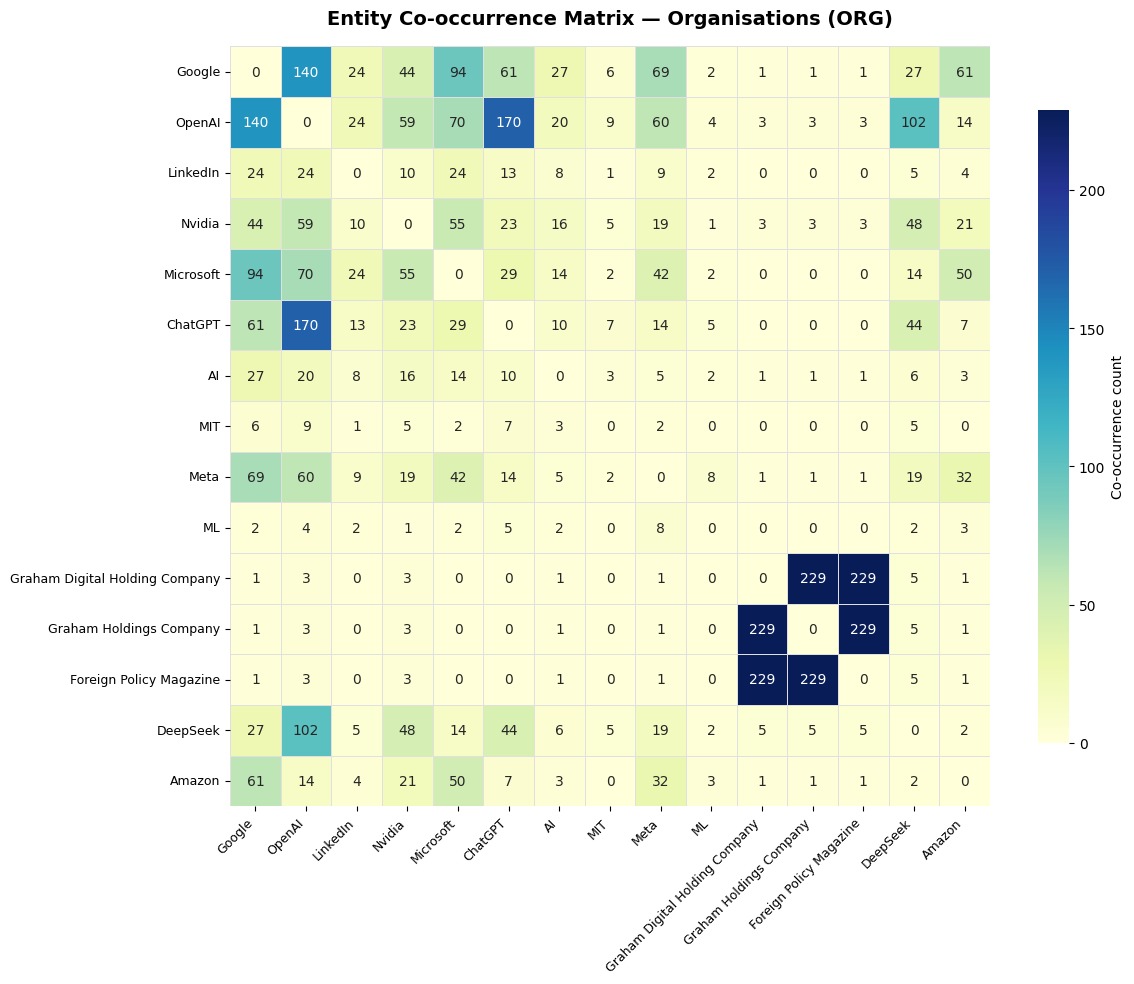

In [ ]:
matrix_org = build_cooc_matrix(results_clean, entity_type="ORG")

plot_cooc_matrix(
    matrix_org,
    title="Entity Co-occurrence Matrix — Organisations (ORG)",
    color="YlGnBu",
)

The Co-occurrence Matrix reveals that **OpenAI & ChatGPT** (170) and **Google & Microsoft** (94) are the most frequently co-mentioned organisation pairs, reflecting the intense media focus on the competitive dynamics between these major AI players.

**DeepSeek & OpenAI** (102) also shows a notably high
co-occurrence, likely driven by the significant media attention around DeepSeek's emergence as a competitive alternative to OpenAI's models in early 2025.

Interestingly, **Graham Digital Holding Company**, **Graham Holdings Company**, and **Foreign Policy Magazine** form an isolated cluster with very high mutual co-occurrence (229) but near-zero co-occurrence with all other organisations, suggesting they appear together exclusively in a specific subset of articles unrelated to the broader AI discourse.

Next, we look at the People Co-occurrence Matrix:

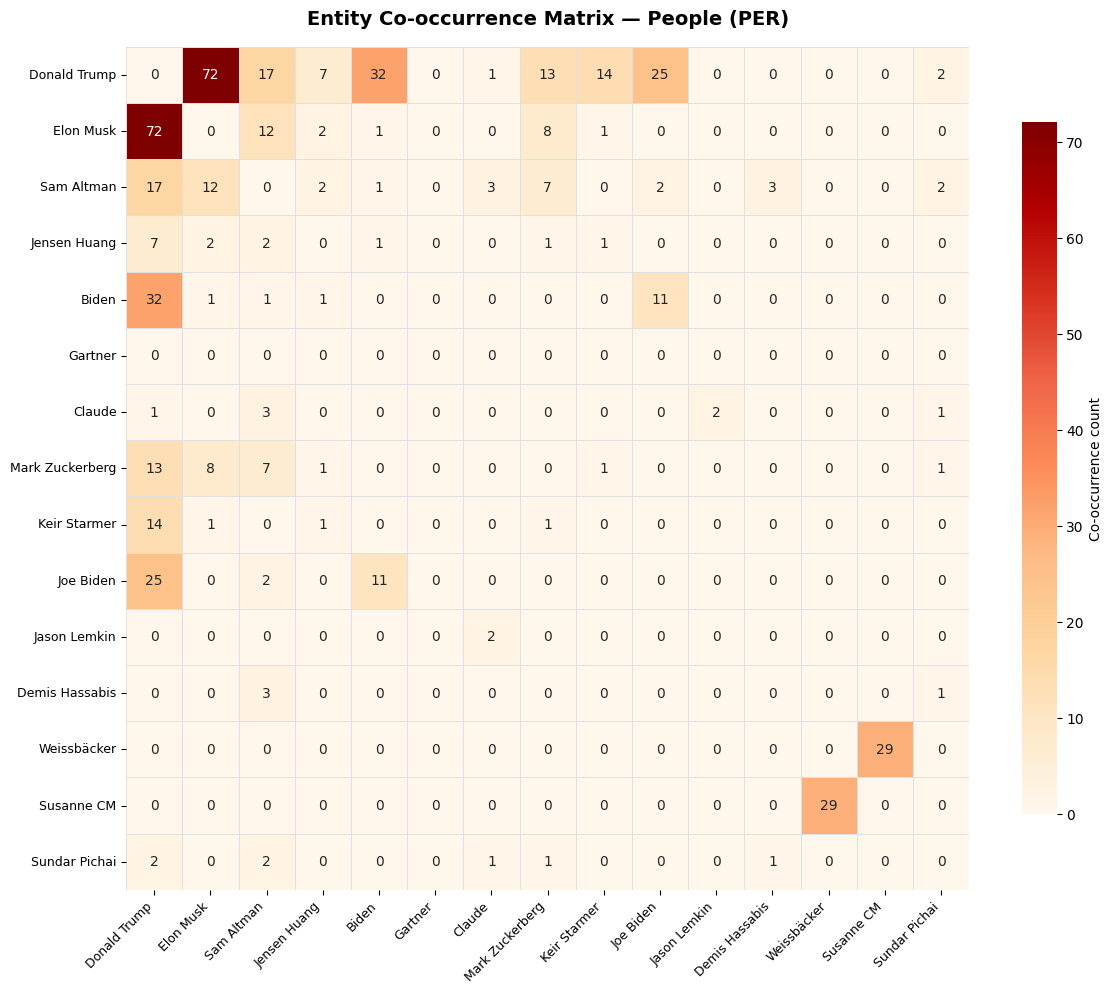

In [ ]:
matrix_per = build_cooc_matrix(results_clean, entity_type="PER")

plot_cooc_matrix(
    matrix_per,
    title="Entity Co-occurrence Matrix — People (PER)",
    color="OrRd",
)

The people co-occurrence matrix is dominated by the **Donald Trump & Elon Musk** pair (72), reflecting their frequent joint media coverage likely driven by their close political and business relationship during the dataset period.

**Donald Trump** emerges as the most central figure overall, co-appearing frequently with Biden (32), Joe Biden (25), Mark Zuckerberg (13), and Keir Starmer (14), suggesting that AI media coverage is heavily intertwined with political discourse.

Similar to the organisations matrix, **Susanne CM & Weissbäcker** form an isolated cluster (29) with near-zero co-occurrence with all other people, indicating they appear together in a specific niche subset of articles separate from mainstream AI discourse.

Furthermore, we look at the Entity Co-occurrence Matrix regarding Locations:

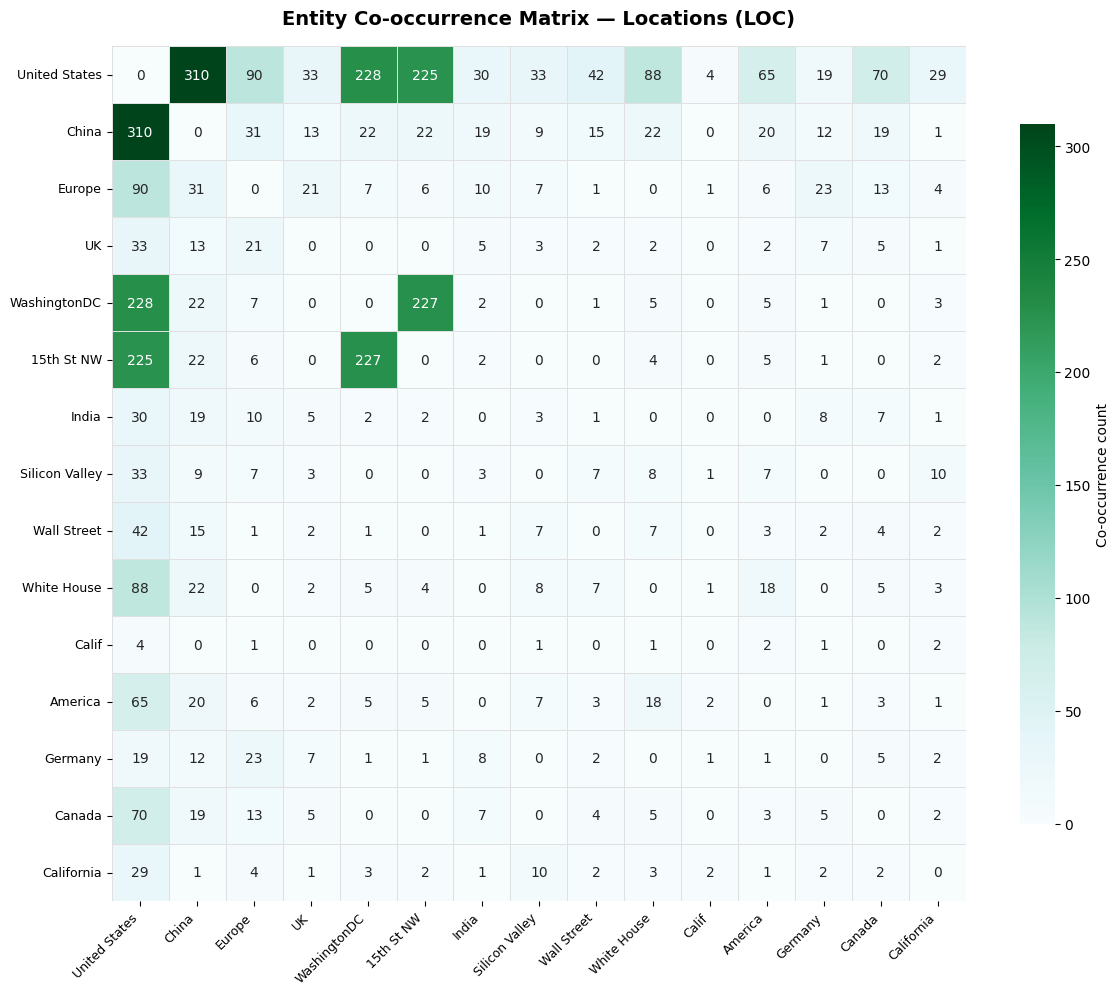

In [ ]:
matrix_loc = build_cooc_matrix(results_clean, entity_type="LOC")

plot_cooc_matrix(
    matrix_loc,
    title="Entity Co-occurrence Matrix — Locations (LOC)",
    color="BuGn",
)

The locations co-occurrence matrix is dominated by the **United States & China** pair (310), by far the highest co-occurrence in the entire matrix, strongly reflecting the ongoing media narrative around the US-China AI race and geopolitical competition in AI development.

**Washington DC & 15th St NW** (227) and **Washington DC & United States** (228) form another tight cluster, suggesting a significant concentration of AI policy and regulatory discourse centered around the US capital.

Notably, **White House & United States** (88) and **Silicon Valley & United States** (33) further reinforce that AI media coverage is heavily US-centric, framing AI developments through both a political and tech industry lens.

Beyond organisations, people, and locations, the NER model also extracted a range of miscellaneous entities including acronyms, technologies, and policy-related terms. The following matrix captures how frequently these MISC entities co-occur within the same articles.

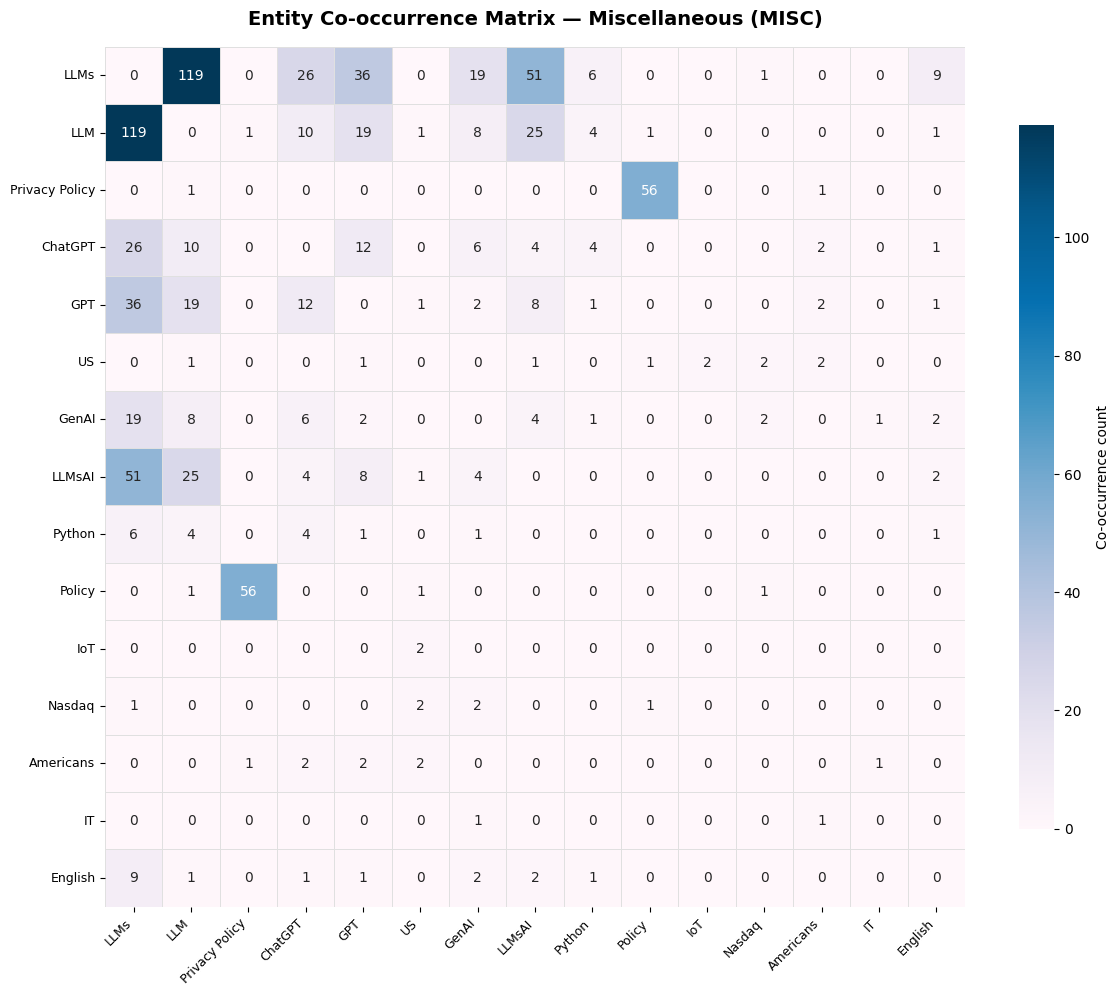

In [ ]:
# MISC is noisy, filter near-universal terms
IGNORE_MISC = IGNORE_TERMS | {"AI", "Chinese", "American", "European"}

matrix_misc = build_cooc_matrix(results_clean, entity_type="MISC", ignore=IGNORE_MISC)

plot_cooc_matrix(
    matrix_misc,
    title="Entity Co-occurrence Matrix — Miscellaneous (MISC)",
    color="PuBu",
)

The miscellaneous entity matrix confirms the dominance of LLM-related
terminology, with **LLMs & LLM** (119) and **LLMs & LLMsAI** (51) showing
the highest co-occurrences, reflecting the fragmented but related ways
media refers to large language models across different articles.

**GPT & LLMs** (36) and **ChatGPT & LLMs** (26) further reinforce that GPT-based models are
the most discussed LLM family in the dataset, consistent with what we observed
in the tags word cloud earlier.

Notably, **Privacy Policy & Policy** (56) forms
an isolated pair with minimal connection to other terms, suggesting a distinct
subset of articles focused specifically on AI governance and data privacy
regulations.

## 7. Knowledge Graph Construction

Building on the entity co-occurrence matrices from the previous section, we now construct a **Knowledge Graph** to formally represent the relationships between entities extracted from the AI Media Dataset.

Where the co-occurrence matrices showed us raw frequency counts between entity pairs, the knowledge graph transforms these relationships into a structured network where **nodes represent entities** (organisations, people, locations, and MISC terms) and **edges represent co-occurrence relationships** weighted by their frequency.

We use the following libraries to build, analyze, and visualize the graph:
- **NetworkX** - graph construction and network metric computation
- **Matplotlib** - graph visualization with color-mapped edge weights
- **itertools.combinations** - efficiently generating entity pairs per document
- **collections.defaultdict & Counter** - counting and aggregating co-occurrences
- **pickle** — saving the knowledge graph for reuse in Stage 3

In [ ]:
import networkx as nx
import matplotlib.cm as cm
import pickle
from itertools import combinations
from collections import defaultdict
from collections import defaultdict, Counter
import matplotlib.colors as mcolors

In [ ]:
# Initialize empty graph and frequency counters
G = nx.Graph()
node_freq = Counter()
edge_weight = defaultdict(int)

# Count entity frequencies and pairwise co-occurrences across all documents
for doc_entities in results_clean:
    words = list({e["word"].strip() for e in doc_entities if len(e["word"].strip()) >= 2})
    for w in words:
        node_freq[w] += 1
    for e1, e2 in combinations(words, 2):
        edge_weight[tuple(sorted([e1, e2]))] += 1

# Add nodes to graph with their frequency as an attribute
for word, freq in node_freq.items():
    G.add_node(word, frequency=freq)

# Add edges only if entities co-occur in at least 2 documents (noise filter)
for (e1, e2), w in edge_weight.items():
    if w >= 2:
        G.add_edge(e1, e2, weight=w)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Nodes: 40493, Edges: 31931


The resulting knowledge graph contains **40'493 nodes** and **31'931 edges**, where each node represents a unique entity extracted from the dataset and each edge connects two entities that co-occurred in at least 2 articles. The relatively lower number of edges compared to nodes suggests that most
entities are specialized terms that only co-occur with a limited set of other entities, rather than being broadly interconnected.

In [ ]:
pagerank    = nx.pagerank(G, weight='weight')
degree_cent = nx.degree_centrality(G)

# Approximate betweenness using only 500 sample nodes — much faster on large graphs
between = nx.betweenness_centrality(G, weight='weight', k=500)

print("Top 10 by PageRank:")
for node, score in sorted(pagerank.items(), key=lambda x: -x[1])[:10]:
    print(f"  {node}: {score:.4f}")

Top 10 by PageRank:
  AI: 0.0461
  AIAI: 0.0091
  Google: 0.0068
  OpenAI: 0.0062
  U. S.: 0.0060
  Trump: 0.0043
  China: 0.0041
  Microsoft: 0.0037
  ChatGPT: 0.0034
  United States: 0.0034


The PageRank analysis confirms that **AI** is by far the most central entity in the knowledge graph (score 0.0461), acting as the primary hub connecting most other entities, nearly 5x more influential than the second ranked entity.
Among the remaining top 10, a mix of **tech companies** (Google, OpenAI, Microsoft, ChatGPT), **geopolitical entities** (U.S., China, United States), and **political
figures** (Trump) reflects the technical and political nature of AI media discourse.

In [ ]:
top_nodes = [n for n in sorted(pagerank, key=pagerank.get, reverse=True)
             if n != "AIAI"][:50]

Gsub = G.subgraph(top_nodes).copy()

In [ ]:
pos = nx.kamada_kawai_layout(Gsub)

In [ ]:
pr_vals     = np.array([pagerank[n] for n in Gsub.nodes()])
norm        = mcolors.Normalize(vmin=pr_vals.min(), vmax=pr_vals.max())
cmap        = cm.plasma
node_colors = [cmap(norm(v)) for v in pr_vals]
node_sizes  = 200 + 5000 * (pr_vals / pr_vals.max())

In [ ]:
edges   = list(Gsub.edges(data=True))
weights = np.array([d.get("weight", 1) for _, _, d in edges])
edge_alpha = np.clip(weights / weights.max(), 0.15, 0.9) if weights.max() > 0 else [0.3] * len(edges)

/tmp/ipykernel_599/3211258441.py:5: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


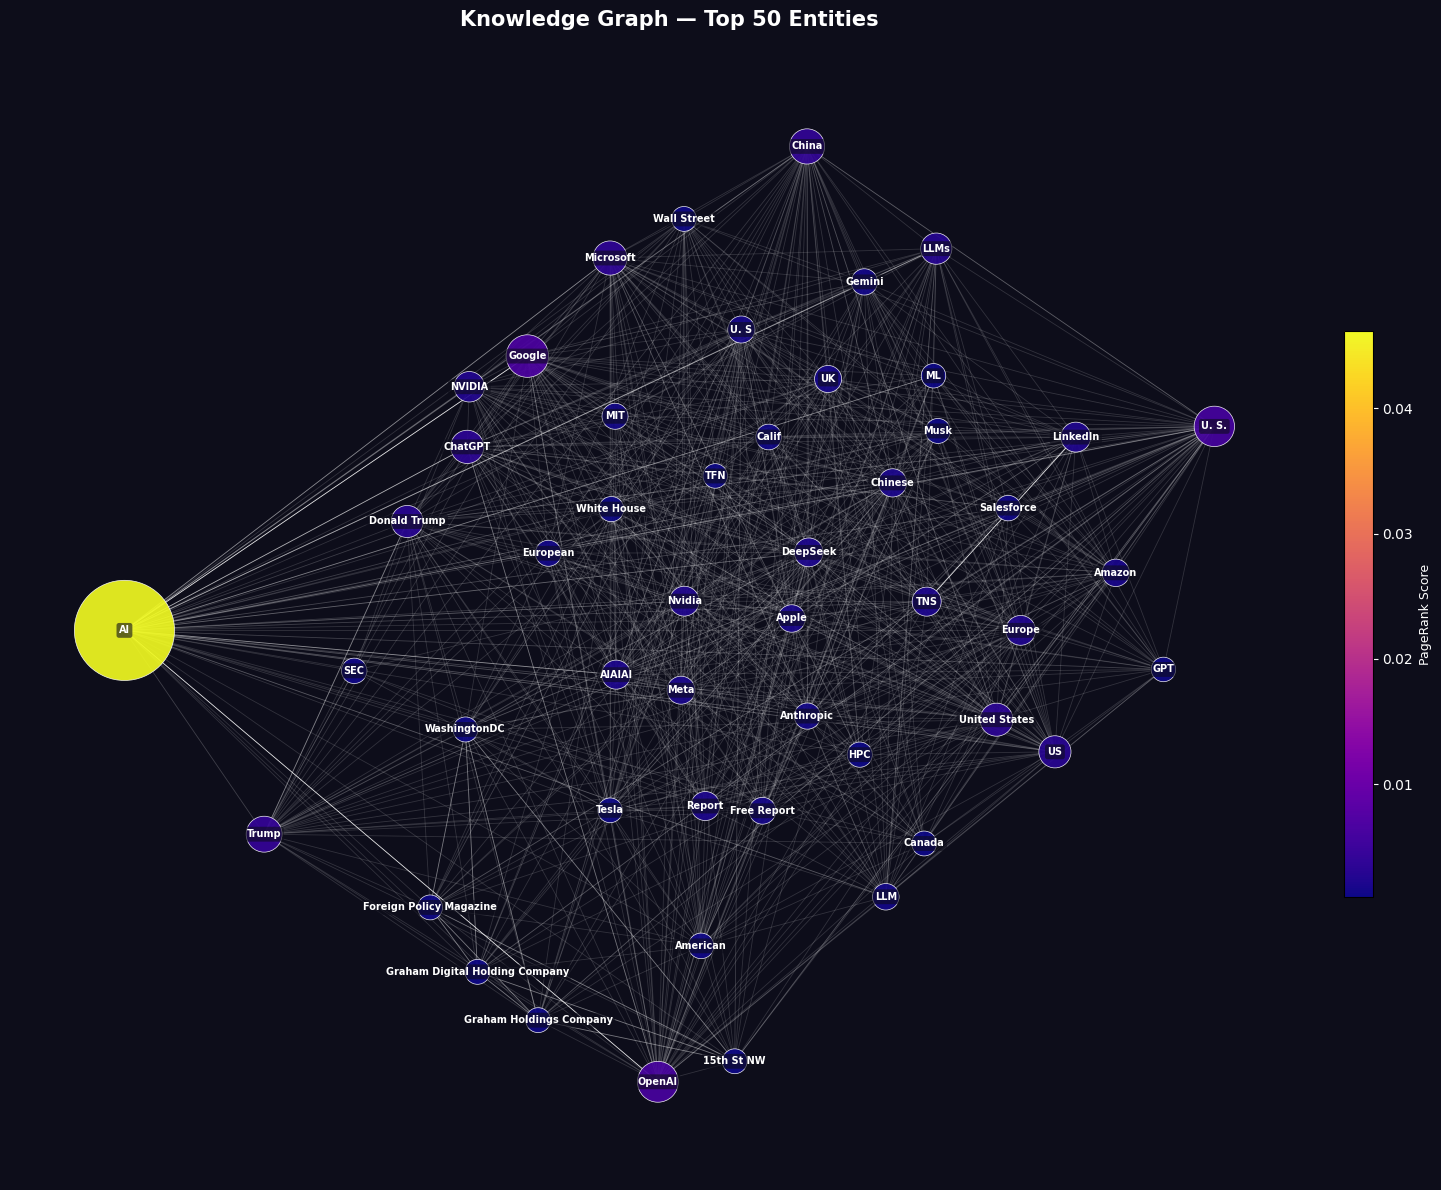

In [ ]:
fig, ax = plt.subplots(figsize=(16, 12), facecolor="#0d0d1a")
ax.set_facecolor("#0d0d1a")

# Edges
nx.draw_networkx_edges(
    Gsub, pos,
    edge_color=["#ffffff"] * len(edges),
    alpha=list(edge_alpha),
    width=0.6,
    ax=ax,
    connectionstyle="arc3,rad=0.05"
)

# Nodes
nx.draw_networkx_nodes(
    Gsub, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.92,
    linewidths=0.5,
    edgecolors="white",
    ax=ax
)

# Labels (all nodes)
labels = {n: n for n in Gsub.nodes()}
nx.draw_networkx_labels(
    Gsub, pos,
    labels=labels,
    font_size=7,
    font_color="white",
    font_weight="bold",
    bbox=dict(boxstyle="round,pad=0.25", fc="#0d0d1a", ec="none", alpha=0.6),
    ax=ax
)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("PageRank Score", color="white", fontsize=9)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

# Title & render
ax.set_title("Knowledge Graph — Top 50 Entities", color="white",
             fontsize=15, fontweight="bold", pad=16)
ax.axis("off")
plt.tight_layout()
plt.show()

The knowledge graph again visually confirms **AI** as the overwhelmingly dominant central hub (bright yellow, largest node), connecting to virtually every other entity in the graph, consistent with its PageRank score of 0.0461
which was nearly 5x higher than any other entity. **U.S.**, **Google**, **OpenAI**, and **Microsoft** form the next tier of influential nodes (larger purple/blue nodes), acting as secondary hubs that bridge technological, geopolitical, and corporate discourse in AI media. The isolated cluster of **Graham Holdings Company**, **Graham Digital
Holding Company**, **Foreign Policy Magazine**, and **15th St NW** on the left side of the graph is consistent with what we observed in the co-occurrence matrices, confirming these entities form a distinct niche subset disconnected from mainstream AI discourse.

In [ ]:
#with open("knowledge_graph.pkl", "wb") as f:
    pickle.dump(G, f)

#print("Graph saved!")

IndentationError: unexpected indent (3981469332.py, line 2)

## 8. Topic Modelling

### 8. 1 LDA Topic Modelling

To identify the main themes present in the AI media articles, we applied topic modeling to the processed article content. For topic modeling, the processed text needed to be represented as lists of tokens rather than a single string so we converted the pre-processed texts into token lists by splitting each document into individual words.

Next, we created a dictionary of unique words across the corpus using Gensim. The dictionary assigns a unique integer ID to every word appearing in the corpus. To reduce noise and remove extremely rare words, we filtered words appearing in fewer than 5 documents and kept the top 50'000 most frequent words. This helps us improve the quality of our topic modelling.

After building the dictionary, we converted the dataset into a bag-of-words (BoW) representation. Each document became a list of (word_id, frequency) pairs. This format describes which words appear in each document and how often. This corpus representation is the required input format for training the LDA model.

In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 98.2 MB/s eta 0:00:00


In [ ]:
from gensim import corpora

# Tokenize
texts = df["content_processed"].apply(lambda x: x.split())

# Create a dictionary
dictionary = corpora.Dictionary(texts)

# Filter words in fewer than 5 documents and keep top 50,000 words
dictionary.filter_extremes(no_below=5, keep_n=50000)

# Create a bag of words corpus
corpus = [dictionary.doc2bow(text) for text in texts]

# Sanity Checks
print(corpus[0])
print(dictionary[0])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 2), (7, 1), (8, 19), (9, 2), (10, 1), (11, 2), (12, 2), (13, 1), (14, 6), (15, 2), (16, 2), (17, 1), (18, 2), (19, 1), (20, 1), (21, 1), (22, 2), (23, 1), (24, 1), (25, 1), (26, 1), (27, 2), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 1), (61, 1), (62, 5), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1), (69, 7), (70, 1), (71, 2), (72, 1), (73, 1), (74, 3), (75, 1), (76, 13), (77, 1), (78, 1), (79, 1), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 1), (87, 2), (88, 1), (89, 1), (90, 1), (91, 1), (92, 1), (93, 2), (94, 1), (95, 2), (96, 1), (97, 1), (98, 2), (99, 1), (100, 1), (101, 1), (102, 1), (103, 1), (104, 1), (105, 1), (106, 1), (107, 1), (108, 1), (109, 5), (110, 1

Latent Dirichlet Allocation (LDA) was used to identify underlying topics in the corpus using the key parameters:

- num_topics = 5 - which specifies the number of topics the model should identify
- passes = 10 - which tells the algorithm the number of iterations to make through the entire dataset so in our case ten times to improve convergence
- random_state = 42 to ensure reproducibility of the results

After training the model, we extracted the four most important words per topic.

In [ ]:
import gensim

# Define LDA model
ldamodel = gensim.models.ldamodel.LdaModel(
    corpus,
    num_topics = 5,
    id2word = dictionary,
    passes = 10,
    random_state = 42
)

In [ ]:
# Print the three topics from the model with top words
topics = ldamodel.print_topics(num_words = 4)
for topic in topics:
	print(topic)

(0, '0.010*"quantum" + 0.007*"energy" + 0.006*"computing" + 0.006*"nvidia"')
(1, '0.009*"share" + 0.009*"market" + 0.007*"stock" + 0.007*"report"')
(2, '0.005*"human" + 0.005*"study" + 0.004*"health" + 0.004*"patient"')
(3, '0.010*"google" + 0.009*"user" + 0.007*"customer" + 0.007*"search"')
(4, '0.007*"cloud" + 0.007*"agent" + 0.006*"customer" + 0.005*"learning"')


The LDA model identified 5 distinct topics across the dataset, each capturing a coherent theme: **quantum computing & hardware** (Topic 0), **financial markets & stocks** (Topic 1), **AI in healthcare** (Topic 2), **search & consumer products** (Topic 3), and **cloud computing & AI agents** (Topic 4). The low topic weights (all below 0.010) suggest that no single term strongly dominates any topic, reflecting the broad and diverse vocabulary used across AI media articles.

In [ ]:
pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 96.0 MB/s eta 0:00:00


Visualizing Topic Structure

To better understand the relationships between topics, we visualized the model using pyLDAvis. This visualization provides a two-dimensional map of topic distances, the relative size of each topic and the most salient words associated with each topic. The intertopic distance map helps evaluate how distinct or overlapping the discovered topics are within the corpus.

We first tried visualizing with 10 topics from the LDA model however that lead to a lot of overlapping bubbles so according to our observation, we decided the best optimum number of topics for our datasets is 5 which is displayed below.

In [ ]:
import pyLDAvis.gensim

# Visualize
lda_display = pyLDAvis.gensim.prepare(ldamodel, corpus, dictionary, sort_topics = False)


pyLDAvis.display(lda_display)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Each bubble represents a topic. The larger the bubble the more prevalent the topic is. You can click on each topic to get the details of the topic on the right hand side. The words are the most important key words that select the specific topic. A good topic will have fairly big non-overlapping bubbles scattered throughout the charts. A good topic will have fairly big non-overlapping bubbles scattered throughout the chart. A buble with too many topics will have many overlaps or small sized bubbles clustered in one region.

The intertopic distance map reveals that the 5 topics are **reasonably well separated**, with Topics 1 and 5 clearly distinct in the upper region, while
Topics 3 and 4 show some overlap suggesting shared vocabulary between **cloud/agent** and **search/consumer** themes. Topic 2 stands alone in the lower right, consistent with its focus on **financial markets**, which is
thematically distinct from the other AI-focused topics. The most salient terms overall, "user", "cloud", "market", "agent", reflect the dataset's strong emphasis on commercial and business applications of AI.

### 8. 2 Hierarchical Topic Modelling

To further explore the thematic structure of the dataset, we applied **BERTopic**, a transformer-based topic modeling approach that uses sentence embeddings to cluster semantically similar documents into coherent topics.

Unlike LDA which relies on word co-occurrence probabilities, BERTopic captures **semantic meaning** directly from the text, making it better suited for identifying nuanced AI-related themes.

After training the model on the cleaned article texts, we generated a **hierarchical topic structure** by iteratively merging similar topics based on semantic similarity. The resulting **dendrogram** visualizes how smaller,
specific topics combine into broader thematic clusters, revealing relationships between AI subtopics at multiple levels of abstraction.

In [ ]:
pip install bertopic

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Convert to full sentences
docs = df["content_clean"].tolist()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from bertopic import BERTopic

# Initialise model
topic_model = BERTopic()

# Train model
topics, probs = topic_model.fit_transform(docs)

# View discovered topics
topic_model.get_topic_info()

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.date

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.date

BERTopic identified **209 topics** in total, significantly more than LDA's 5 topics, demonstrating BERTopic's ability to capture fine-grained thematic distinctions within the dataset. The largest topic (Topic -1) contains **5'769 outlier documents** that could not be clearly assigned to any specific
topic, this is normal BERTopic behavior where ambiguous or highly diverse documents are grouped into a noise cluster. The remaining topics reveal a rich variety of AI-related themes ranging from **quantum computing** (Topic 1), **cybersecurity** (Topic 3), and **Trump's federal AI policy** (Topic 206) to
more niche topics like **protein folding/AlphaFold** (Topic 205) and **Bitcoin mining** (Topic 203).

To better understand how the 209 BERTopic topics relate to each other, we visualize their hierarchical structure using a dendrogram. This reveals how individual fine-grained topics merge into broader thematic clusters, providing a multi-level view of AI media discourse.

In [ ]:
# Generate hierarchical topics
hierarchical_topics = topic_model.hierarchical_topics(docs)

# Visualize the hierarchy
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-awa

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

The hierarchical clustering dendrogram reveals that BERTopic's 209 topics organize into several broad thematic super-clusters, with the x-axis representing semantic distance between topics, shorter branches indicate highly similar topics while longer branches indicate more distinct ones.
Several coherent macro-themes emerge clearly from the hierarchy: a **financial & stock markets** cluster (shares, stocks earnings), a **healthcare & medical research** cluster (clinical trials, pharma, radiology), a **geopolitics & regulation** cluster (Trump, EU AI Act, China semiconductors, UK government), and a **core AI technology** cluster (LLMs, RAG, agents, cloud, developers). Notably, the **creative & social** themes (art, music, film, deepfakes, children online safety) cluster together separately from technical AI topics, confirming that AI media coverage extends well beyond
pure technology into cultural and societal discourse. The long blue branchesconnecting the major super-clusters at the far right indicate that these broad themes are semantically very distinct from each other.

### 8. 3 Topic Distribution Over Time

After generating topics using the LDA model, we analyzed how the discovered topics evolved across different months in the dataset.

**Dominant Topic Assignment**:

Since LDA assigns each document a probability distribution over all topics,
we selected the **highest probability topic** as the dominant topic for each
article, resulting in a single topic label per document.

**Aggregating Topic Frequencies by Month**:

We then grouped the dataset by month and dominant topic, counting the number
of articles associated with each topic per month. To make the visualization
more readable, topics were manually mapped to descriptive labels based on
their most prominent keywords.


In [ ]:
# Apply most dominant topic to each document
df["topic"] = [max(ldamodel.get_document_topics(doc), key=lambda x: x[1])[0] for doc in corpus]

# Group by the month and topic and count number of Articles for each topic
topic_time = df.groupby(["month","topic"]).size().reset_index(name="count")


Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.date

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

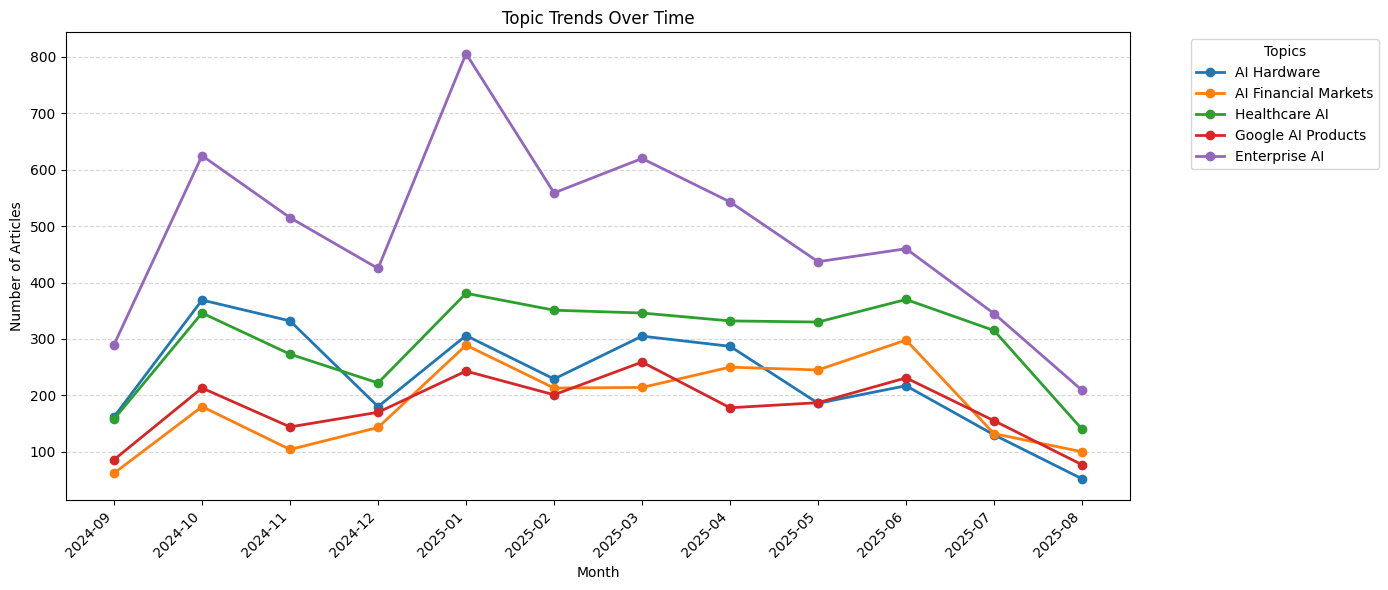

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
# Provided the topic labels based on the first few important words
import matplotlib.pyplot as plt


topic_labels = {
    0: "AI Hardware",
    1: "AI Financial Markets",
    2: "Healthcare AI",
    3: "Google AI Products",
    4: "Enterprise AI"
}

# Plot Number of Articles per Topic Over Time
plt.figure(figsize=(14, 6))

for topic in sorted(topic_time["topic"].unique()):
    subset = topic_time[topic_time["topic"] == topic]
    plt.plot(
        subset["month"].astype(str),
        subset["count"],
        marker="o",
        linewidth=2,
        label=topic_labels[topic]
    )

plt.xticks(rotation=45, ha="right")
plt.title("Topic Trends Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.legend(title="Topics", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Enterprise AI** dominates media coverage throughout the entire period, peaking sharply in January 2025 (around 800 articles) before gradually declining, consistent with the January surge we observed in our earlier temporal analysis, likely driven by major enterprise AI announcements and product launches at the start of the year as seen before.

**Healthcare AI** remains the second
most covered topic with relatively stable coverage (around 300-380 articles), suggesting sustained rather than trend-driven media interest in AI medical applications.

**AI Financial Markets** and **Google AI Products** show the lowest and most stable coverage throughout the period, while **AI Hardware**
follows a similar declining trend to Enterprise AI toward August 2025, reflecting the general decrease in article volume.

### 8. 4 Sentiment Distribution After Topic Modelling

After assigning a dominant topic to each article using the LDA model, we aggregated sentiment scores to examine how sentiment values were distributed across the topics.

A bar chart was created to visualize the average sentiment score associated with each topic.



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

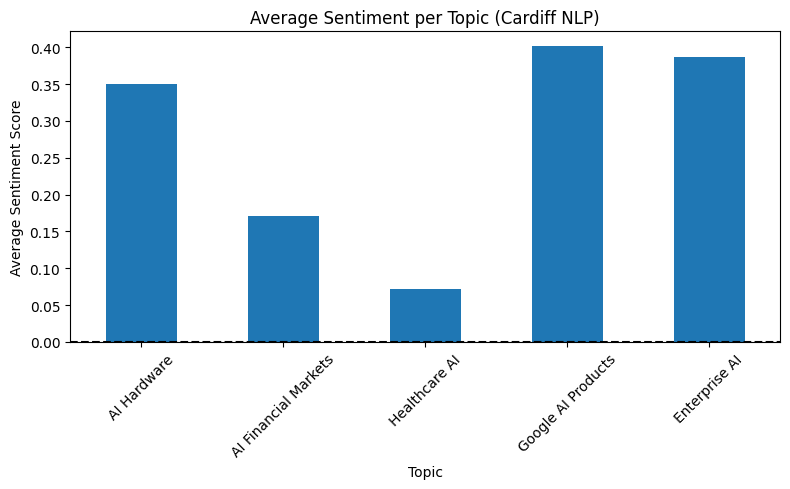

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
# Convert Cardiff label + score into a signed sentiment value
df["cardiff_sentiment"] = df.apply(
    lambda x: x["cardiff_score"] if x["cardiff_label"] == "positive"
    else -x["cardiff_score"] if x["cardiff_label"] == "negative"
    else 0,
    axis=1
)

# Group topics by Cardiff sentiment
topic_sentiment = df.groupby("topic")["cardiff_sentiment"].mean()

# Map labels
topic_sentiment.index = topic_sentiment.index.map(topic_labels)

# Visualize the average Cardiff sentiment per topic
plt.figure(figsize=(8, 5))
topic_sentiment.plot(kind="bar")

plt.title("Average Sentiment per Topic (Cardiff NLP)")
plt.xlabel("Topic")
plt.ylabel("Average Sentiment Score")
plt.axhline(0, color="black", linestyle="--")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**The Cardiff NLP sentiment analysis** shows that all identified topics have a generally positive average sentiment.

Among them, Google AI Products and Enterprise AI exhibit the highest positive sentiment scores, indicating that articles related to these topics tend to express more favorable language.

AI Hardware also shows relatively strong positive sentiment (0.35), while AI Financial Markets (0.15) has a more moderate score.

Healthcare AI records the lowest average sentiment (0.05) among the topics, though it remains slightly positive overall.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

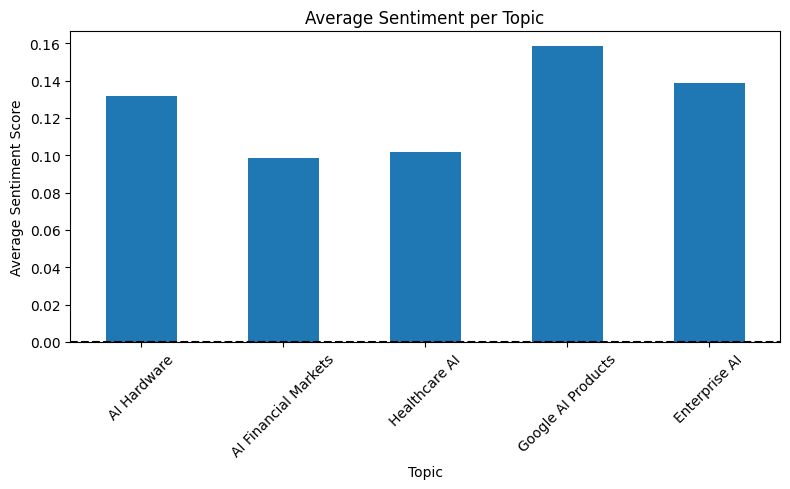

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
# Group Topics by Sentiments
topic_sentiment = df.groupby("topic")["sentiment"].mean()

# Map Labels
topic_sentiment.index = topic_sentiment.index.map(topic_labels)

# Visualize the Average Sentiment per Topic
plt.figure(figsize=(8,5))

topic_sentiment.plot(kind="bar")

plt.title("Average Sentiment per Topic")
plt.xlabel("Topic")
plt.ylabel("Average Sentiment Score")
plt.axhline(0, color="black", linestyle="--")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**The TextBlob sentiment analysis **shows that all topics have slightly positive average sentiment scores.

Google AI Products again has the highest average sentiment (0.16), indicating more positive language in articles related to this topic.

Enterprise AI and AI Hardware also show moderately positive sentiment.

AI Financial Markets and Healthcare AI display lower but still positive average sentiment scores, suggesting a more neutral tone in articles discussing these themes.

## 9. AI-Tools used

Throughout this project, we used AI assistants (Claude and ChatGPT) to generate first drafts of code implementations, markdown explanations, and visualization interpretations.

All AI-generated content was critically reviewed, adjusted, and validated by the whole team before inclusion in the notebook. The final analysis, interpretations and conclusions reflect the team's own understanding and judgment.

## 10. Contributions



The project work was carried out collaboratively by Nick, Julian, and Samuel. Each member initially worked on the different components of the analysis individually. The results and code were then brought together, reviewed collectively, and integrated into a single workflow. During this process, adjustments and refinements were made jointly to ensure consistency, improve the analysis, and finalize the overall structure of the project.